<a href="https://colab.research.google.com/github/PriadiCuanda-231401058/Capstone-Project-Eye-Nemia/blob/main/Eye_nemia.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone Project : Eye-Nemia
Eye-Nemia adalah sistem skrining risiko anemia berbasis web untuk membantu mendeteksi risiko anemia pada wanita usia produktif secara dini. Sistem ini menggunakan data pola makan, kondisi menstruasi, kebiasaan konsumsi, dan gejala pengguna untuk memprediksi tingkat risiko anemia (rendah, sedang, tinggi).

## Menentukan Pertanyaan Bisnis

Pertanyaan bisnis utama:

1. Manakah dari 42 variabel (seperti pola makan, volume darah menstruasi, dan gejala klinis) yang merupakan 5 prediktor terkuat dalam memicu risiko anemia, sehingga tenaga kesehatan dapat memprioritaskan program penyuluhan dan intervensi gizi tepat sasaran pada implementasi sistem?
2. Apa 3 faktor pola makan utama (seperti defisit konsumsi daging merah, sayuran hijau, atau suplemen zat besi) yang berkorelasi paling tinggi terhadap lonjakan risiko anemia menjadi 'Tinggi' pada wanita usia produktif, sehingga tim medis dapat merancang materi kampanye gizi yang tepat sasaran pada kuartal depan?
3. Di antara pasien yang sedang hamil (Currently_Pregnant == 'Ya'), variabel manakah (apakah defisit nutrisi makanan, kurangnya suplemen, atau tingkat aktivitas yang tinggi) yang paling dominan menyebabkan mereka masuk ke dalam kategori Risiko Anemia Tinggi, guna perbaikan prosedur perawatan antenatal (kehamilan) bulan ini

## Import Semua Packages/Library yang Digunakan

In [78]:
import pandas as pd
import numpy as np
import joblib
import scipy.stats as ss
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')


from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

# Data Wrangling

Tahapan data wrangling dilakukan untuk memastikan dataset memiliki kualitas yang baik sebelum masuk ke tahap exploratory data analysis (EDA) dan modeling.

Tahapan utama meliputi:
- Gathering Data
- Assessing Data
- Cleaning Data

## Gathering Data

Pada tahap ini, dataset dikumpulkan dan dimuat ke dalam environment Google Colab untuk dilakukan pemeriksaan awal.

In [79]:
# https://drive.google.com/file/d/1xSvfYLRAZaUe4jEvpNDDl0MMLKq-E8le/view?usp=sharing (Dataset baru)
# https://drive.google.com/file/d/1MJAgFYbbsE1_SEDRZyXLpG6COH7kXxz3/view?usp=drive_link (Dataset Lama)
# https://drive.google.com/file/d/163ozdwZluUFs3QD8mm9lIdIwkL5dUQi6/view?usp=sharing (Dataset Baru (Risk_Score Numerik))

file_id = '163ozdwZluUFs3QD8mm9lIdIwkL5dUQi6'
url = f'https://drive.google.com/uc?export=download&id={file_id}'

anemia_df = pd.read_csv(url)

anemia_df.head()

,Age,Gender,Height_cm,Weight_kg,Marital_Status,Currently_Pregnant,History_Anemia,Family_History_Anemia,Ever_Checked_Hb,Menstruation_Days,...,Symptom_PaleSkin,Symptom_Headache,Symptom_Breathlessness,Symptom_LowFocus,Symptom_ColdExtremities,Symptom_Palpitation,Symptom_HairLoss,Symptom_Weakness,Symptom_DaytimeSleepiness,Risk_Score
0,45.0,Perempuan,166.0,56.257377,Menikah,Tidak,Tidak,Tidak,Tidak,3.0,...,Tidak pernah,Tidak pernah,Tidak pernah,Tidak pernah,Tidak pernah,Tidak pernah,Jarang,Tidak pernah,Tidak pernah,0
1,46.0,Perempuan,152.0,63.988786,Belum Menikah,Tidak,Tidak,Tidak,Tidak,3.0,...,Jarang,Tidak pernah,Tidak pernah,Tidak pernah,Jarang,Tidak pernah,Jarang,Tidak pernah,Tidak pernah,36
2,16.0,Perempuan,153.0,42.595274,Bercerai,Tidak,Ya,Ya,Tidak,7.0,...,Kadang-kadang,Kadang-kadang,Jarang,Kadang-kadang,Sering,Kadang-kadang,Jarang,Kadang-kadang,Sering,6
3,23.0,Perempuan,150.0,80.600000,Bercerai,Tidak,Tidak,Tidak,Tidak,3.0,...,Jarang,Tidak pernah,Tidak pernah,Jarang,Jarang,Tidak pernah,Tidak pernah,Jarang,Tidak pernah,0
4,26.0,Perempuan,147.0,55.747951,Bercerai,Tidak,Tidak,Tidak,Tidak,3.0,...,Jarang,Tidak pernah,Jarang,Jarang,Tidak pernah,Tidak pernah,Tidak pernah,Tidak pernah,Tidak pernah,5


In [80]:
# Melihat ukuran dataset
print(f'Jumlah baris: {anemia_df.shape[0]}')
print(f'Jumlah kolom: {anemia_df.shape[1]}')

Jumlah baris: 20066
Jumlah kolom: 43


### Data Dictionary

| Kolom | Tipe Data | Deskripsi |
|---|---|---|
| **Age** | Numerik (Float) | Usia pasien (dalam tahun). |
| **Gender** | Kategorikal | Jenis kelamin pasien. |
| **Height_cm** | Numerik (Float) | Tinggi badan pasien dalam sentimeter (cm). |
| **Weight_kg** | Numerik (Float) | Berat badan pasien dalam kilogram (kg). |
| **Marital_Status** | Kategorikal | Status pernikahan pasien (misal: 'Belum Menikah'). |
| **Currently_Pregnant** | Kategorikal | Status kehamilan pasien saat pendataan ('Ya' / 'Tidak'). |
| **Menstruation_Days** | Numerik (Float) | Lama durasi hari keluarnya darah menstruasi per siklus. |
| **Regular_Menstruation** | Kategorikal | Status keteraturan siklus menstruasi bulanan ('Ya' / 'Tidak'). |
| **Menstrual_Blood_Volume** | Ordinal | Perkiraan volume/jumlah darah yang keluar saat menstruasi (misal: 'Sedikit', 'Banyak'). |
| **History_Anemia** | Kategorikal | Apakah pasien memiliki riwayat didiagnosis anemia sebelumnya ('Ya' / 'Tidak'). |
| **Family_History_Anemia** | Kategorikal | Apakah ada riwayat penyakit anemia di dalam keluarga pasien ('Ya' / 'Tidak'). |
| **Ever_Checked_Hb** | Kategorikal | Apakah pasien pernah melakukan pemeriksaan tes darah/Hemoglobin sebelumnya ('Ya' / 'Tidak'). |
| **Consume_RedMeat** | Ordinal | Frekuensi konsumsi daging merah (sumber utama zat besi). |
| **Consume_Liver** | Ordinal | Frekuensi konsumsi hati hewan (ayam/sapi). |
| **Consume_Egg** | Ordinal | Frekuensi konsumsi telur. |
| **Consume_Fish** | Ordinal | Frekuensi konsumsi ikan. |
| **Consume_GreenVeg** | Ordinal | Frekuensi konsumsi sayuran hijau (sumber zat besi non-heme). |
| **Consume_Nuts** | Ordinal | Frekuensi konsumsi kacang-kacangan. |
| **Consume_FruitVitC** | Ordinal | Frekuensi konsumsi buah-buahan bersumber Vitamin C (membantu penyerapan zat besi). |
| **Iron_Supplement** | Kategorikal | Status pasien dalam meminum suplemen tambah darah/zat besi ('Ya' / 'Tidak'). |
| **Eat_Breakfast** | Kategorikal | Kebiasaan sarapan di pagi hari ('Ya' / 'Tidak'). |
| **Meal_Frequency_Per_Day** | Ordinal | Jumlah/frekuensi makan besar dalam sehari (misal: '1x', '3x'). |
| **Tea_After_Meal** | Ordinal | Kebiasaan minum teh segera setelah makan (penghambat zat besi). |
| **Coffee_After_Meal** | Ordinal | Kebiasaan minum kopi setelah makan (penghambat zat besi). |
| **Junk_Food_Frequency** | Ordinal | Frekuensi konsumsi makanan cepat saji (*junk food*). |
| **Water_Intake_Glasses** | Numerik (Float) | Jumlah air putih yang diminum dalam sehari (satuan gelas). |
| **Physical_Activity** | Ordinal | Tingkat aktivitas fisik atau olahraga harian. |
| **Stress_Level** | Ordinal | Tingkat stres yang dialami pasien (misal: 'Sedang', 'Tinggi'). |
| **Busyness_Level** | Ordinal | Tingkat kesibukan aktivitas harian (misal: 'Cukup Sibuk', 'Sibuk'). |
| **Sleep_Hours_Per_Day** | Numerik (Float) | Rata-rata jam tidur pasien dalam satu hari. |
| **Gadget_Hours_Per_Day** | Numerik (Float) | Rata-rata paparan layar/gadget dalam sehari. |
| **Symptom_Fatigue** | Ordinal | Tingkat seringnya merasakan kelelahan tanpa alasan jelas. |
| **Symptom_Dizziness** | Ordinal | Tingkat seringnya merasakan pusing / berkunang-kunang. |
| **Symptom_PaleSkin** | Ordinal | Tingkat kepucatan pada kulit, bibir, atau kelopak mata (parameter utama Anemia). |
| **Symptom_Headache** | Ordinal | Frekuensi mengalami sakit kepala. |
| **Symptom_Breathlessness** | Ordinal | Frekuensi mengalami sesak napas / napas pendek. |
| **Symptom_LowFocus** | Ordinal | Frekuensi kesulitan untuk fokus / menurunnya konsentrasi. |
| **Symptom_ColdExtremities** | Ordinal | Frekuensi merasakan dingin pada bagian ujung tubuh (telapak tangan/kaki). |
| **Symptom_Palpitation** | Ordinal | Frekuensi jantung berdebar cepat. |
| **Symptom_HairLoss** | Ordinal | Tingkat keparahan kerontokan rambut. |
| **Symptom_Weakness** | Ordinal | Frekuensi badan terasa lemas secara keseluruhan. |
| **Symptom_DaytimeSleepiness** | Ordinal | Tingkat rasa kantuk berlebihan pada siang hari. |
| **Risk_Score (Target)** | Numerik (Int)| Nilai potensi risiko anemia |

In [81]:
anemia_df['Risk_Score'].nunique()

101

## Assessing Data

Tahap assessing data dilakukan untuk memahami struktur dataset serta mengidentifikasi potensi masalah pada data seperti:
- Missing values
- Tipe data tidak sesuai
- Duplikasi data
- Inkonsistensi penamaan
- Outlier

In [82]:
# Melihat keseluruhan struktur dataset
anemia_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20066 entries, 0 to 20065
Data columns (total 43 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Age                        20034 non-null  float64
 1   Gender                     17222 non-null  object 
 2   Height_cm                  20027 non-null  float64
 3   Weight_kg                  20027 non-null  float64
 4   Marital_Status             20064 non-null  object 
 5   Currently_Pregnant         20027 non-null  object 
 6   History_Anemia             20019 non-null  object 
 7   Family_History_Anemia      20012 non-null  object 
 8   Ever_Checked_Hb            20035 non-null  object 
 9   Menstruation_Days          20004 non-null  float64
 10  Regular_Menstruation       20064 non-null  object 
 11  Menstrual_Blood_Volume     20004 non-null  object 
 12  Consume_RedMeat            20066 non-null  object 
 13  Consume_Liver              20066 non-null  obj

In [83]:
numerik = anemia_df.select_dtypes(include=['int64', 'float64'])
kategorik = anemia_df.select_dtypes(include=['object', 'category', 'bool'])

print("Kolom Numerik:")
print(numerik.columns.tolist())

print("\nKolom Kategorik:")
print(kategorik.columns.tolist())

print("\nJumlah fitur numerik:", len(numerik.columns))
print("Jumlah fitur kategorik:", len(kategorik.columns))

Kolom Numerik:
['Age', 'Height_cm', 'Weight_kg', 'Menstruation_Days', 'Water_Intake_Glasses', 'Sleep_Hours_Per_Day', 'Gadget_Hours_Per_Day', 'Risk_Score']

Kolom Kategorik:
['Gender', 'Marital_Status', 'Currently_Pregnant', 'History_Anemia', 'Family_History_Anemia', 'Ever_Checked_Hb', 'Regular_Menstruation', 'Menstrual_Blood_Volume', 'Consume_RedMeat', 'Consume_Liver', 'Consume_Egg', 'Consume_Fish', 'Consume_GreenVeg', 'Consume_Nuts', 'Consume_FruitVitC', 'Iron_Supplement', 'Eat_Breakfast', 'Meal_Frequency_Per_Day', 'Tea_After_Meal', 'Coffee_After_Meal', 'Junk_Food_Frequency', 'Physical_Activity', 'Stress_Level', 'Busyness_Level', 'Symptom_Fatigue', 'Symptom_Dizziness', 'Symptom_PaleSkin', 'Symptom_Headache', 'Symptom_Breathlessness', 'Symptom_LowFocus', 'Symptom_ColdExtremities', 'Symptom_Palpitation', 'Symptom_HairLoss', 'Symptom_Weakness', 'Symptom_DaytimeSleepiness']

Jumlah fitur numerik: 8
Jumlah fitur kategorik: 35


###**Insight Struktur Dataset**


- Dataset terdiri dari **20.066 baris** dan **43 kolom**, sehingga jumlah data sudah cukup besar untuk dilakukan analisis dan pengembangan model machine learning.

- Dataset memiliki kombinasi fitur:
  - **Numerik (`float64`)** seperti usia, tinggi badan, berat badan, durasi menstruasi, konsumsi air, durasi tidur, dan aktivitas fisik.
  - **Kategorikal (`object`)** seperti pola makan, kebiasaan konsumsi, gejala anemia, dan tingkat stres.

- Beberapa kolom memiliki **missing values**, terlihat dari jumlah `non-null count` yang lebih kecil dibanding total data. Hal ini menunjukkan perlunya proses data cleaning sebelum analisis lebih lanjut.

- Sebagian besar fitur dalam dataset berkaitan langsung dengan faktor risiko anemia, seperti:
  - pola konsumsi makanan sumber zat besi,
  - kondisi menstruasi,
  - kebiasaan minum teh/kopi,
  - serta gejala fisik yang dialami pengguna.

- Kolom `Risk_Score` diduga menjadi target utama dalam proses analisis/modeling untuk menentukan tingkat risiko anemia pengguna.

In [84]:
# Statistik deskriptif
anemia_df.describe(include='all')

,Age,Gender,Height_cm,Weight_kg,Marital_Status,Currently_Pregnant,History_Anemia,Family_History_Anemia,Ever_Checked_Hb,Menstruation_Days,...,Symptom_PaleSkin,Symptom_Headache,Symptom_Breathlessness,Symptom_LowFocus,Symptom_ColdExtremities,Symptom_Palpitation,Symptom_HairLoss,Symptom_Weakness,Symptom_DaytimeSleepiness,Risk_Score
count,20034.000000,17222,20027.000000,20027.000000,20064,20027,20019,20012,20035,20004.000000,...,20066,20066,20066,20066,20066,20066,20066,20066,20066,20066.000000
unique,NaN,1,NaN,NaN,3,2,2,2,2,NaN,...,5,5,5,5,5,5,5,5,5,NaN
top,NaN,Perempuan,NaN,NaN,Menikah,Tidak,Tidak,Tidak,Tidak,NaN,...,Tidak pernah,Tidak pernah,Tidak pernah,Tidak pernah,Tidak pernah,Tidak pernah,Jarang,Tidak pernah,Tidak pernah,NaN
freq,NaN,17222,NaN,NaN,7153,16687,10132,10584,12589,NaN,...,6611,5607,6150,5318,5812,7789,6015,6367,5795,NaN
mean,35.402166,NaN,153.893125,58.390996,NaN,NaN,NaN,NaN,NaN,5.368026,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,52.895046
std,12.182461,NaN,12.277348,15.046535,NaN,NaN,NaN,NaN,NaN,3.499227,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,36.291989
min,-1.000000,NaN,-5.000000,-5.000000,NaN,NaN,NaN,NaN,NaN,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
25%,24.000000,NaN,146.000000,49.072023,NaN,NaN,NaN,NaN,NaN,3.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17.000000
50%,37.000000,NaN,152.170000,58.348769,NaN,NaN,NaN,NaN,NaN,5.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,55.000000
75%,47.000000,NaN,160.000000,67.952204,NaN,NaN,NaN,NaN,NaN,7.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.000000


###**Insight Statistik Deskriptif**

Berdasarkan hasil ringkasan statistik, dataset ini menunjukkan karakteristik data mentah (kotor) dengan berbagai anomali yang perlu ditangani sebelum masuk ke tahap pemodelan. Berikut adalah rincian insight-nya:

**1. Gambaran Umum & Missing Values**
* Total baris data secara keseluruhan adalah sekitar **20.066 baris** (merujuk pada jumlah *count* maksimal di kolom `Risk_Score` dan gejala).
* Terdapat perbedaan nilai `count` pada setiap kolom (misalnya `Gender` hanya 17.222, `Menstruation_Days` 20.004). Hal ini mengindikasikan adanya masalah **Missing Values (data kosong)** yang tersebar di hampir seluruh fitur.

**2. Fitur Numerikal (Indikasi Anomali & Outlier Ekstrem)**
* **Age (Usia):** Usia rata-rata responden adalah 35,4 tahun. Namun, terdapat *outlier* yang sangat tidak logis secara biologis, yaitu nilai minimum **-1 tahun** dan nilai maksimum **161 tahun**.
* **Height_cm (Tinggi Badan):** Rata-rata tinggi responden adalah 153,89 cm (cukup wajar untuk populasi perempuan). Sayangnya, kolom ini memiliki anomali parah dengan nilai minimum **-5 cm** dan maksimum **999 cm**.
* **Weight_kg (Berat Badan):** Rata-rata berat badan adalah 58,39 kg. Sama halnya dengan tinggi badan, terdapat input yang tidak valid dengan nilai minimum **-5 kg** dan maksimum **917 kg**.
* **Menstruation_Days (Hari Menstruasi):** Rata-rata durasi menstruasi adalah sekitar 5 hari (5,36), namun terdapat nilai maksimum hingga **30 hari** yang patut diinvestigasi lebih lanjut (apakah ini anomali atau indikasi penyakit tertentu).
* **Risk_Score (Skor Risiko):** Kolom target ini sudah berupa numerik dengan rentang nilai yang logis, yaitu minimum **0** hingga maksimum **100**, dengan nilai rata-rata (mean) di angka **52,89**.

**3. Fitur Kategorikal**
* **Gender:** Hanya memiliki **1 nilai unik** (kardinalitas tunggal) yaitu `Perempuan` sebanyak 17.222 baris. Sisanya (sekitar 2.844 baris) kemungkinan adalah *missing value* (NaN).
* **Status Demografi & Medis Dasar:**
  * Mayoritas status responden adalah **Menikah** (`Menikah`: 7.153 dari 20.064).
  * Sebagian besar responden **Tidak** sedang hamil (`Tidak`: 16.687).
  * Mayoritas **Tidak** memiliki riwayat anemia pribadi (`Tidak`: 10.132) maupun riwayat anemia keluarga (`Tidak`: 10.584).
  * Sebagian besar responden **Tidak** pernah mengecek kadar Hemoglobin (Hb) sebelumnya (`Tidak`: 12.589).
* **Symptom (Gejala-Gejala):** Terdapat 5 tingkat jawaban (kategori) untuk berbagai kolom gejala (seperti pucat, pusing, sesak napas, dsb). Jawaban mayoritas *(top frequency)* yang paling banyak diisi oleh responden untuk hampir seluruh gejala adalah **"Tidak pernah"**.

**Kesimpulan untuk Tindakan Selanjutnya (Data Cleaning):**
Data ini wajib melalui proses *cleaning* yang ketat. Nilai minus (-1, -5) dan angka tak wajar (161 tahun, tinggi 999 cm) harus dihapus, diimputasi, atau difilter secara medis agar tidak merusak logika model Machine Learning nantinya.

Number of numeric Risk Score entries: 20066
Number of non-numeric (categorical) Risk Score entries: 0


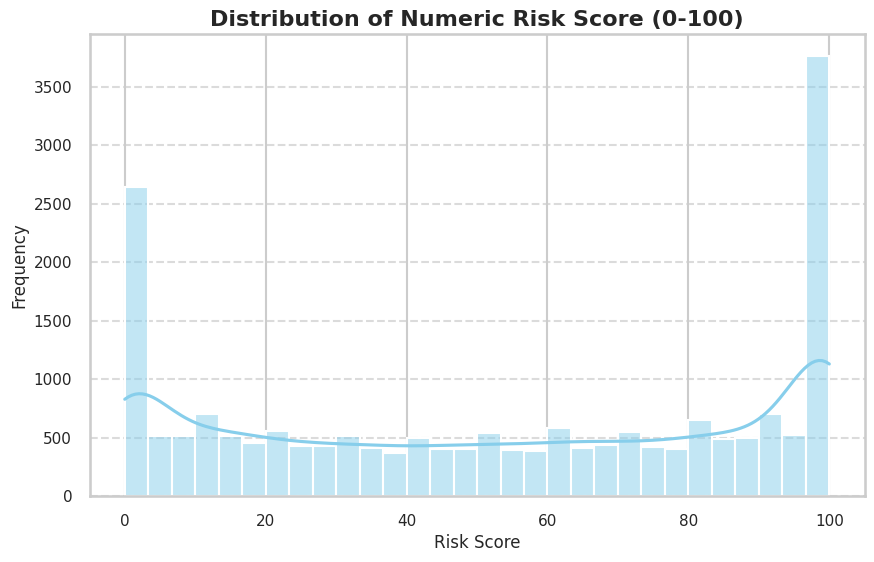


Descriptive statistics for Numeric Risk Score:
count    20066.000000
mean        52.895046
std         36.291989
min          0.000000
25%         17.000000
50%         55.000000
75%         89.000000
max        100.000000
Name: Risk_Score, dtype: float64


In [85]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Buang data Null untuk melihat distribusi
numeric_risk_scores = anemia_df['Risk_Score'].dropna()

print(f"Number of numeric Risk Score entries: {len(numeric_risk_scores)}")
print(f"Number of non-numeric (categorical) Risk Score entries: {anemia_df['Risk_Score'].isna().sum()}")

# Plot visualisasi distribusi
plt.figure(figsize=(10, 6))
sns.histplot(numeric_risk_scores, kde=True, bins=30, color='skyblue')
plt.title('Distribution of Numeric Risk Score (0-100)', fontsize=16)
plt.xlabel('Risk Score', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print("\nDescriptive statistics for Numeric Risk Score:")
print(numeric_risk_scores.describe())

###**Insight Statistik: Numerikal `Risk_Score`**

Berdasarkan hasil ringkasan statistik untuk target variabel `Risk_Score`, data ini menunjukkan karakteristik yang bersih dan sangat representatif jika dibandingkan dengan fitur *input* lainnya yang masih kotor. Berikut adalah rincian insight-nya:

**1. Kelengkapan dan Validitas Data**
* **Jumlah Data (*Count*):** Terdapat **20.066** baris data yang valid. Jika dibandingkan dengan jumlah baris keseluruhan dataset, ini berarti tidak ada *missing value* (data kosong) pada kolom target ini.
* **Rentang Nilai (*Min - Max*):** Nilai terendah adalah **0** dan tertinggi adalah **100**. Rentang ini sangat logis dan valid untuk sebuah metrik persentase atau indeks risiko. Tidak ditemukan anomali atau *outlier* yang tidak masuk akal (seperti nilai minus atau di atas 100).

**2. Distribusi dan Pemusatan Data**
* **Rata-rata & Nilai Tengah (*Mean & Median*):** Rata-rata skor risiko berada di angka **52,89**, dengan nilai tengah (*median* / 50%) di angka **55**. Kedekatan antara *mean* dan *median* mengindikasikan bahwa seolah distribusi data ini secara umum cukup seimbang dan tidak mengalami kemiringan yang parah (*skewness* ekstrem).
* **Sebaran Data (*Standard Deviation*):** Nilai standar deviasi cukup tinggi, yaitu **36,29**. Hal ini menunjukkan bahwa skor risiko responden sangat bervariasi dan menyebar luas di sepanjang rentang 0-100, alih-alih hanya menumpuk di nilai rata-ratanya.

**3. Analisis Kuartil (Pemetaan Kelompok Risiko)**
* **Batas Bawah (25%):** Seperempat (25%) dari total responden memiliki skor risiko yang sangat rendah, yaitu di bawah **17**.
* **Batas Atas (75%):** Seperempat responden lainnya berada di zona risiko yang sangat tinggi, dengan skor di atas **89**.

** Implikasi untuk Pemodelan Machine Learning:**
Karakteristik target variabel numerik ini **sangat ideal**. Sebaran skor yang luas dari ujung ke ujung akan memudahkan algoritma (*regresi* maupun *deep learning*) untuk mengenali batas sinyal yang tegas. Jika Anda berencana mengubah pendekatan dari regresi menjadi klasifikasi (*Low, Medium, High*), Anda dapat memanfaatkan nilai-nilai kuartil ini (17 dan 89) sebagai batas ambang (*threshold*) yang objektif untuk memecah data secara proporsional

In [86]:
# Melihat missing values
missing_values = anemia_df.isnull().sum()
missing_values[missing_values > 0]

,0
Age,32
Gender,2844
Height_cm,39
Weight_kg,39
Marital_Status,2
Currently_Pregnant,39
History_Anemia,47
Family_History_Anemia,54
Ever_Checked_Hb,31
Menstruation_Days,62


In [87]:
missing_percentage = (anemia_df.isnull().sum() / len(anemia_df)) * 100
missing_percentage[missing_percentage > 0].sort_values(ascending=False)

,0
Gender,14.173228
Menstrual_Blood_Volume,0.308980
Menstruation_Days,0.308980
Family_History_Anemia,0.269112
Water_Intake_Glasses,0.234227
History_Anemia,0.234227
Stress_Level,0.234227
Height_cm,0.194359
Busyness_Level,0.194359
Weight_kg,0.194359


**Insight Missing Values**

- Ditemukan missing values pada beberapa kolom dalam dataset,
  baik pada fitur numerik maupun kategorikal.

- Kolom dengan jumlah missing values tertinggi adalah:
  - `Gender` (14.17%) → akan di-drop karena seluruh data adalah
    wanita sehingga kolom ini tidak memberikan informasi berarti.
  - `Menstruation_Days` (~0.31%)
  - `Menstrual_Blood_Volume` (~0.31%)
  - `Family_History_Anemia` (~0.27%)

- Di luar kolom `Gender`, persentase missing values pada seluruh
  kolom lainnya sangat kecil (< 1%), sehingga kehilangan data
  masih tergolong rendah dan tidak memengaruhi distribusi dataset
  secara signifikan.

- Strategi penanganan missing values akan ditentukan di tahap
  Data Cleaning berdasarkan konteks dan logika domain
  masing-masing kolom.

In [88]:
# Melihat duplikasi data
print('Jumlah data duplikat:', anemia_df.duplicated().sum())

Jumlah data duplikat: 0


###**Insight Data Duplikat**

- Hasil pemeriksaan menunjukkan bahwa dataset tidak memiliki data duplikat (`0 duplicated rows`).

In [89]:
# Mengecek nilai unik pada kolom kategorial
categorical_cols = anemia_df.select_dtypes(include='object').columns

for col in categorical_cols:
    print(f'\nKolom: {col}')
    print(anemia_df[col].unique())


Kolom: Gender
['Perempuan' nan]

Kolom: Marital_Status
['Menikah' 'Belum Menikah' 'Bercerai' nan]

Kolom: Currently_Pregnant
['Tidak' 'Ya' nan]

Kolom: History_Anemia
['Tidak' 'Ya' nan]

Kolom: Family_History_Anemia
['Tidak' 'Ya' nan]

Kolom: Ever_Checked_Hb
['Tidak' 'Ya' nan]

Kolom: Regular_Menstruation
['Ya' 'Tidak' nan]

Kolom: Menstrual_Blood_Volume
['Sedikit' 'Sangat Banyak' 'Banyak' 'Normal' nan]

Kolom: Consume_RedMeat
['Kadang (3-4x/minggu)' 'Jarang (1-2x/minggu)' 'Sering (5-6x/minggu)'
 'Setiap hari' 'Tidak pernah']

Kolom: Consume_Liver
['Sering (5-6x/minggu)' 'Kadang (3-4x/minggu)' 'Jarang (1-2x/minggu)'
 'Setiap hari' 'Tidak pernah']

Kolom: Consume_Egg
['Sering (5-6x/minggu)' 'Jarang (1-2x/minggu)' 'Setiap hari'
 'Tidak pernah' 'Kadang (3-4x/minggu)']

Kolom: Consume_Fish
['Setiap hari' 'Sering (5-6x/minggu)' 'Tidak pernah'
 'Jarang (1-2x/minggu)' 'Kadang (3-4x/minggu)']

Kolom: Consume_GreenVeg
['Kadang (3-4x/minggu)' 'Jarang (1-2x/minggu)' 'Sering (5-6x/minggu)'
 'Tida

**Insight Statistik: Eksplorasi Fitur Kategorikal**

Berdasarkan pengecekan nilai unik pada seluruh kolom kategorikal, dataset ini menangkap profil kesehatan, gaya hidup, dan riwayat medis yang sangat komprehensif untuk deteksi risiko anemia. Namun, terdapat beberapa catatan penting terkait kualitas data dan persiapan pemodelan:

**1. Demografi Terfokus & Isu *Missing Values***
* **Kardinalitas Tunggal pada Gender:** Fitur `Gender` hanya berisi nilai `Perempuan` (dan `nan`). Hal ini sangat masuk akal mengingat target utama deteksi dini anemia (terutama dalam project ini) difokuskan pada wanita (karena faktor menstruasi dan kehamilan). Karena tidak ada variansi (hanya 1 nilai valid), **kolom Gender ini nantinya bisa di-drop** saat pemodelan karena tidak memberikan informasi diskriminatif bagi Machine Learning.
* **Kehadiran *Missing Values* (`nan`):** Hampir seluruh fitur kategorikal (mulai dari `Marital_Status`, `History_Anemia`, nutrisi, hingga gaya hidup) memiliki nilai `nan`. Ini mengonfirmasi status data sebagai "data kotor" yang wajib melalui tahapan *imputasi* (misalnya menggunakan *mode/nilai yang paling sering muncul*) sebelum di-encode ataupun didrop jika jumlahnya sedikit.

**2. Kelengkapan Domain Medis Anemia**
* **Faktor Risiko Fisiologis:** Data menangkap informasi vital pemicu anemia secara spesifik, seperti kehamilan (`Currently_Pregnant`), siklus menstruasi (`Regular_Menstruation`), dan yang paling penting: volume darah menstruasi (`Menstrual_Blood_Volume` dengan rentang *Sedikit* hingga *Sangat Banyak*).
* **Faktor Nutrisi (Asupan vs Penghambat Zat Besi):** * Dataset ini sangat luar biasa karena memisahkan asupan penguat zat besi (Daging merah, Hati, Sayuran Hijau, Suplemen) dengan asupan **penghambat penyerapan zat besi** (seperti minum kopi dan teh setelah makan / `Tea_After_Meal`, `Coffee_After_Meal`).
  * Semua variabel nutrisi memiliki skala ukur yang seragam dan rapi (mulai dari *Tidak pernah* hingga *Setiap hari*).

**3. Gejala Klinis (*Symptoms*) yang Terstruktur**
* Seluruh 11 kolom gejala (seperti kelelahan, pusing, pucat, sesak napas) diukur menggunakan skala frekuensi Likert 5 tingkat: `Tidak pernah` -> `Jarang` -> `Kadang-kadang` -> `Sering` -> `Selalu`.
* Hal ini sangat ideal karena frekuensi kemunculan gejala bisa menjadi sinyal kuat (*strong predictors*) bagi model Deep Learning untuk menentukan tingkat risiko (Low/Medium/High).

**Implikasi untuk Tahap Preprocessing (Encoding Strategy):**
Data kategorikal ini memiliki tingkatan/hierarki, sehingga **tidak boleh** semuanya diubah menggunakan *One-Hot Encoding* (pd.get_dummies). Berikut adalah strategi *encoding* yang wajib Anda terapkan:
* **Binary Encoding (0 dan 1):** Berlaku untuk kolom dengan nilai `Ya` / `Tidak` (seperti `Currently_Pregnant`, `History_Anemia`, `Iron_Supplement`).
* **Ordinal Encoding:** Berlaku untuk kolom nutrisi, kebiasaan, dan gejala klinis. Anda harus membuat pemetaan berurutan (*mapping*), misalnya:
  * `Tidak pernah` = 0
  * `Jarang` / `Jarang (1-2x/minggu)` = 1
  * `Kadang-kadang` / `Kadang (3-4x/minggu)` = 2
  * `Sering` / `Sering (5-6x/minggu)` = 3
  * `Selalu` / `Setiap hari` = 4
* **Nominal Encoding / One-Hot:** Hanya berlaku untuk kolom yang tidak memiliki tingkatan pasti, seperti `Marital_Status` (Menikah, Belum Menikah, Bercerai).

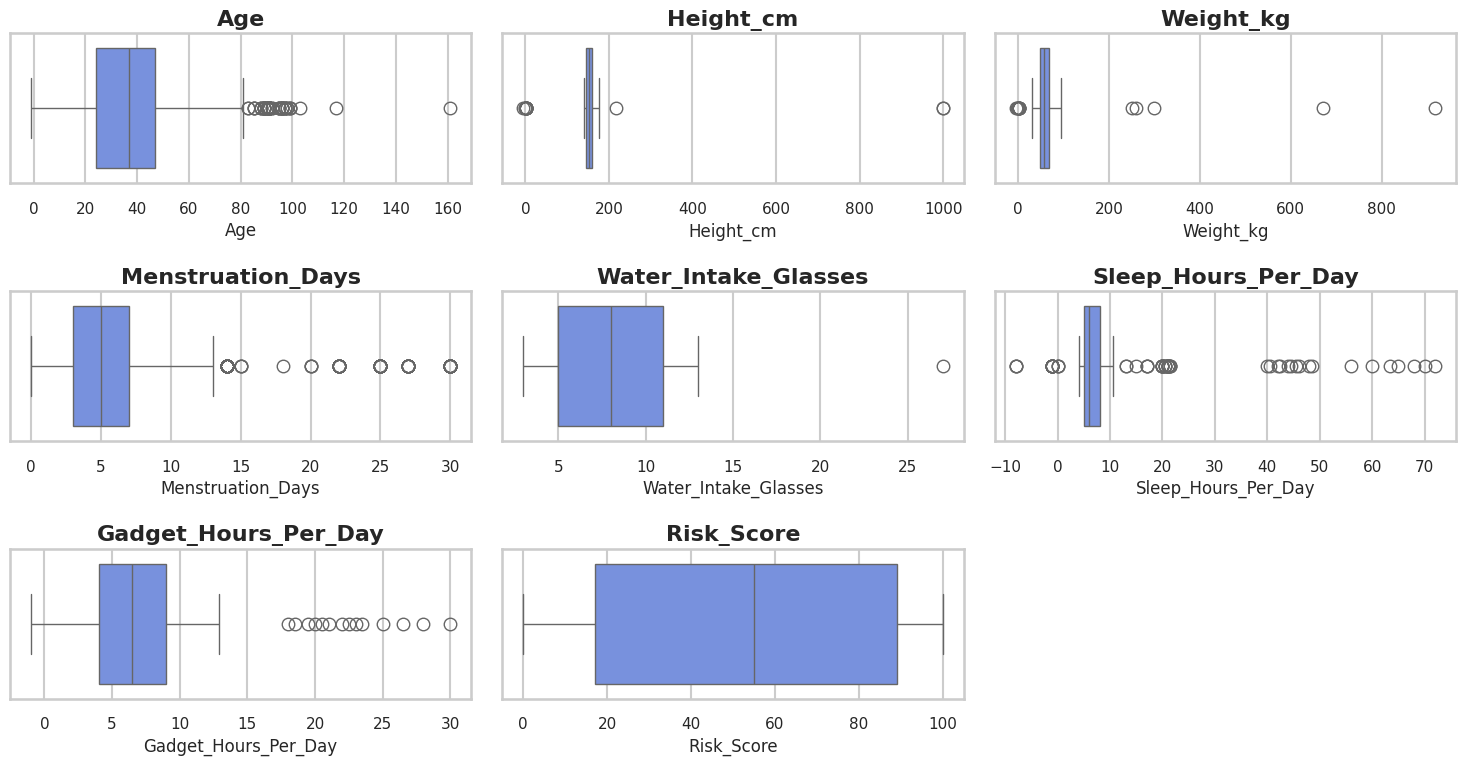

In [90]:
# Deteksi nilai outlier
numerical_cols = anemia_df.select_dtypes(include=['int64', 'float64']).columns

plt.figure(figsize=(15,8))
for i, col in enumerate(numerical_cols):
    plt.subplot((len(numerical_cols)//3)+1, 3, i+1)
    sns.boxplot(x=anemia_df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

**Insight Deteksi Outliers**

Deteksi Outlier: `Menstruation_Days`
Berdasarkan visualisasi *boxplot* untuk distribusi `Menstruation_Days` (Hari Menstruasi), kita dapat menarik beberapa kesimpulan penting terkait sebaran data:
* **Pemusatan Data Normal (Box & Whisker):** Mayoritas responden (berada di dalam kotak/Interquartile Range) memiliki durasi menstruasi yang normal, yaitu di kisaran **3 hingga 7 hari**, dengan nilai tengah (*median*) di angka 5 hari. Hal ini sangat sesuai dengan logika medis pada umumnya.
* **Keberadaan Outlier Ekstrem:** Terdapat sangat banyak titik data (*diamonds/circles* hitam) yang berada jauh di sebelah kanan "kumis" (*whisker*) batas atas. Data ini merepresentasikan durasi menstruasi mulai dari belasan hari hingga maksimum **30 hari**.
* **Tindakan Lanjutan:** Secara medis, menstruasi selama 30 hari berturut-turut merupakan kondisi yang sangat tidak wajar (bisa jadi indikasi penyakit serius atau *input error*). Karena dataset ini adalah data mentah yang sengaja dibuat kotor, *outlier* ini wajib ditangani pada tahap *Data Cleaning* (misalnya dengan teknik *winsorizing* / *capping* ke batas wajar maksimum, atau menghapus baris data yang bernilai di atas 14 hari).

###**Insight Tahap Assessing Data**

Ringkasan Keseluruhan Tahap *Assessing Data*
Setelah melakukan pengecekan melalui statistik deskriptif, nilai unik, dan visualisasi dasar, dataset mentah ini terbukti mengandung berbagai "kekotoran" yang harus dibersihkan sebelum masuk ke tahap pemodelan (*Data Cleaning* & *Preprocessing*). Berikut adalah rekapitulasi masalah utamanya:

1. **Masalah *Missing Values* (Data Kosong)**
   * Hampir seluruh fitur (baik numerik maupun kategorikal seperti demografi, gejala, dan nutrisi) memiliki nilai `NaN`. Proses *imputasi* sangat diperlukan (menggunakan *mean/median* untuk numerik, dan *mode* untuk kategorikal).
   
2. **Masalah Data Tidak Valid & Tidak Logis (*Inconsistent Data*)**
   * Terdapat input yang secara biologis tidak mungkin (anomali fatal), seperti:
     * `Age` (Usia) dengan nilai **-1 tahun** hingga **161 tahun**.
     * `Height_cm` (Tinggi Badan) dengan rentang **-5 cm** hingga **999 cm**.
     * `Weight_kg` (Berat Badan) dengan nilai **-5 kg** hingga **917 kg**.

3. **Masalah Kardinalitas Tunggal (*Zero Variance*)**
   * Fitur `Gender` hanya memiliki satu nilai valid, yaitu **'Perempuan'** (sisanya `NaN`). Karena tidak memiliki variansi data yang bisa dipelajari oleh model untuk membedakan target, kolom ini sebaiknya di-*drop* (dihapus).

4. **Kesiapan Variabel Target (`Risk_Score`)**
   * Berbeda dengan fitur *input*, kolom target numerik `Risk_Score` sudah **bersih dan ideal**. Rentangnya logis (0 - 100), distribusinya sangat baik (rata-rata 52,89, standar deviasi 36,29), dan sama sekali tidak memiliki *missing values*.

5. **Kesiapan Fitur Kategorikal (*Encoding Requirement*)**
   * Kolom fitur nutrisi dan gejala (seperti kelelahan, pusing, makan sayur) memiliki tingkatan skala ordinal yang jelas (misal: *Tidak pernah -> Jarang -> Sering -> Selalu*). Ini memerlukan pendekatan **Ordinal Encoding**.

**Kesimpulan Transisi:** Tahap asesmen telah berhasil memetakan semua "penyakit" di dalam dataset ini. Langkah selanjutnya yang harus dilakukan adalah **Data Cleaning**, dengan fokus utama: menghapus nilai minus/tak wajar, menangani *outlier* pada numerik, melakukan imputasi `NaN`, dan men-drop kolom yang tidak berguna.

## Cleaning Data


Tahap cleaning data dilakukan untuk memperbaiki kualitas dataset sebelum digunakan pada tahap exploratory data analysis dan machine learning.

Proses cleaning meliputi:
- Menangani missing values
- Menstandarisasi data kategorikal
- Memperbaiki tipe data
- Menangani outlier

In [91]:
# Membuat salinan dataset agar data asli tetap aman
df_clean = anemia_df.copy()

###**Validasi Logika & Domain Medis**

In [92]:
drop_cols = [
    'Gender',
    'Marital_Status',
    'Ever_Checked_Hb',
    # 'History_Anemia',
    # 'Family_History_Anemia',
    # 'Iron_Supplement',
    # 'Sleep_Hours_Per_Day',
    # 'Physical_Activity',
    # 'Gadget_Hours_Per_Day',
    # 'Stress_Level',
    # 'Busyness_Level'
]

df_clean = df_clean.drop(columns=drop_cols)
print(f'Shape setelah drop kolom: {df_clean.shape}')
print(f'Kolom tersisa: {df_clean.columns.tolist()}')

Shape setelah drop kolom: (20066, 40)
Kolom tersisa: ['Age', 'Height_cm', 'Weight_kg', 'Currently_Pregnant', 'History_Anemia', 'Family_History_Anemia', 'Menstruation_Days', 'Regular_Menstruation', 'Menstrual_Blood_Volume', 'Consume_RedMeat', 'Consume_Liver', 'Consume_Egg', 'Consume_Fish', 'Consume_GreenVeg', 'Consume_Nuts', 'Consume_FruitVitC', 'Iron_Supplement', 'Eat_Breakfast', 'Meal_Frequency_Per_Day', 'Tea_After_Meal', 'Coffee_After_Meal', 'Junk_Food_Frequency', 'Water_Intake_Glasses', 'Physical_Activity', 'Stress_Level', 'Busyness_Level', 'Sleep_Hours_Per_Day', 'Gadget_Hours_Per_Day', 'Symptom_Fatigue', 'Symptom_Dizziness', 'Symptom_PaleSkin', 'Symptom_Headache', 'Symptom_Breathlessness', 'Symptom_LowFocus', 'Symptom_ColdExtremities', 'Symptom_Palpitation', 'Symptom_HairLoss', 'Symptom_Weakness', 'Symptom_DaytimeSleepiness', 'Risk_Score']


In [93]:
before_rows = df_clean.shape[0]

# Hitung sebelum filter
dropped_age = ((df_clean['Age'] < 15) | (df_clean['Age'] > 49)).sum()
dropped_height = ((df_clean['Height_cm'] < 100) | (df_clean['Height_cm'] > 200)).sum()
dropped_weight = ((df_clean['Weight_kg'] < 20) | (df_clean['Weight_kg'] > 100)).sum()
dropped_sleep = ((df_clean['Sleep_Hours_Per_Day'] < 1) | (df_clean['Sleep_Hours_Per_Day'] > 24)).sum()
dropped_gadget = ((df_clean['Gadget_Hours_Per_Day'] < 0) | (df_clean['Gadget_Hours_Per_Day'] > 24)).sum()

print('=== Nilai Tidak Realistis yang Ditemukan ===')
print(f'Age tidak masuk target (< 15 atau > 49)          : {dropped_age}')
print(f'Height tidak realistis (< 100 atau > 200 cm)  : {dropped_height}')
print(f'Weight tidak realistis (< 20 atau > 100 kg)   : {dropped_weight}')
print(f'Sleep tidak realistis (< 1 atau > 24 jam)     : {dropped_sleep}')
print(f'Gadget tidak realistis (< 0 atau > 24 jam)    : {dropped_gadget}')

# Filter domain
df_clean = df_clean[
    (df_clean['Age'] >= 15) & (df_clean['Age'] <= 49) &
    (df_clean['Height_cm'] >= 100) & (df_clean['Height_cm'] <= 200) &
    (df_clean['Weight_kg'] >= 20) & (df_clean['Weight_kg'] <= 100) &
    (df_clean['Sleep_Hours_Per_Day'] >= 1) & (df_clean['Sleep_Hours_Per_Day'] <= 24) &
    (df_clean['Gadget_Hours_Per_Day'] >= 0) & (df_clean['Gadget_Hours_Per_Day'] <= 24)
]
after_domain = df_clean.shape[0]

# Cross check sleep + gadget
invalid_combined = df_clean[(df_clean['Sleep_Hours_Per_Day'] + df_clean['Gadget_Hours_Per_Day']) > 24]
dropped_sleep_gadget = len(invalid_combined)
df_clean = df_clean[(df_clean['Sleep_Hours_Per_Day'] + df_clean['Gadget_Hours_Per_Day']) <= 24]

# Cross check currently_pregnant vs menstruation_days
invalid_preg1 = df_clean[
    (df_clean['Currently_Pregnant'] == 'Ya') & (df_clean['Menstruation_Days'] > 0)
]
invalid_preg2 = df_clean[
    (df_clean['Currently_Pregnant'] == 'Tidak') & (df_clean['Menstruation_Days'] <= 0)
]

df_clean = df_clean[
    ~(
        ((df_clean['Currently_Pregnant'] == 'Ya') & (df_clean['Menstruation_Days'] > 0)) |
        ((df_clean['Currently_Pregnant'] == 'Tidak') & (df_clean['Menstruation_Days'] <= 0))
    )
]

after_rows = df_clean.shape[0]

print('\n=== Breakdown Data yang Dihapus ===')
print(f'Age tidak realistis                        : {dropped_age}')
print(f'Height tidak realistis                     : {dropped_height}')
print(f'Weight tidak realistis                     : {dropped_weight}')
print(f'Sleep tidak realistis                      : {dropped_sleep}')
print(f'Gadget tidak realistis                     : {dropped_gadget}')
print(f'Sleep + Gadget > 24 jam                    : {dropped_sleep_gadget}')
print(f'Hamil tapi mens_day > 0                    : {len(invalid_preg1)}')
print(f'Tidak hamil tapi mens_day <= 0             : {len(invalid_preg2)}')
print(f'─────────────────────────────────────────────')
print(f'Total dihapus                              : {before_rows - after_rows}')
print(f'Data tersisa                               : {after_rows}')

=== Nilai Tidak Realistis yang Ditemukan ===
Age tidak masuk target (< 15 atau > 49)          : 214
Height tidak realistis (< 100 atau > 200 cm)  : 15
Weight tidak realistis (< 20 atau > 100 kg)   : 14
Sleep tidak realistis (< 1 atau > 24 jam)     : 36
Gadget tidak realistis (< 0 atau > 24 jam)    : 9

=== Breakdown Data yang Dihapus ===
Age tidak realistis                        : 214
Height tidak realistis                     : 15
Weight tidak realistis                     : 14
Sleep tidak realistis                      : 36
Gadget tidak realistis                     : 9
Sleep + Gadget > 24 jam                    : 34
Hamil tapi mens_day > 0                    : 1777
Tidak hamil tapi mens_day <= 0             : 0
─────────────────────────────────────────────
Total dihapus                              : 2275
Data tersisa                               : 17791


**Insight Validasi Logika & Domain Medis**

Proses *filtering* ini membuktikan betapa pentingnya menerapkan **Domain Knowledge** (pengetahuan medis dan batasan dunia nyata) dalam membersihkan dataset sintetis maupun data mentah. Secara total, kita telah menghapus **2.275 baris data tidak valid**, menyisakan **17.791 baris data yang kini sudah bersih dan logis**.

Berikut adalah rincian temuan dari proses pembersihan data ini:

**1. Filter Demografi Target (Wanita Usia Subur)**
* **Age (Usia):** Sebanyak 214 baris data dihapus karena berada di luar rentang 15–49 tahun. Langkah ini sangat tepat karena fokus proyek deteksi anemia ini adalah pada **Wanita Usia Subur (WUS)**. Usia di luar rentang tersebut memiliki standar fisiologis dan faktor risiko anemia yang sama sekali berbeda (misal: anak-anak atau lansia/menopause).

**2. Filter Anomali Fisik dan Waktu**
* **Tinggi & Berat Badan:** 15 data tinggi badan dan 14 data berat badan dihapus karena tidak realistis (misalnya nilai minus atau mencapai ratusan kilogram/sentimeter). Ini mengeliminasi *noise* ekstrem yang kita temukan pada tahap *Assessing Data* sebelumnya.
* **Logika Waktu (Jam/Hari):** Menghapus data yang melanggar hukum fisika waktu. Ada 36 data tidur tidak wajar, 9 data *gadget* tidak wajar, dan 34 data di mana total jam tidur + jam gadget melebihi 24 jam sehari. Jika dibiarkan, model akan kebingungan mempelajari pola kebiasaan yang mustahil terjadi ini.

**3. Filter Logika Medis Utama (Kontradiksi Fisiologis)**
* **Hamil vs Menstruasi:** Ini adalah penemuan paling krusial dari keseluruhan proses. Terdapat 1.777 baris data yang mencatat responden berstatus "Sedang Hamil" tetapi memiliki "Hari Menstruasi di atas 0" (sedang haid). Secara medis, wanita hamil tidak mengalami menstruasi.
* Penghapusan 1.777 anomali fatal ini menyelamatkan model Machine Learning kita dari kesesatan pola. Jika tidak dihapus, model bisa mengira bahwa wanita hamil juga kehilangan darah melalui menstruasi, yang akan merusak perhitungan prediksi Risk Score anemia.

**Kesimpulan Kesiapan Data:**
Dengan terhapusnya data anomali dan kontradiktif ini, dataset yang tersisa (17.791 baris) kini memiliki integritas logika yang tinggi. Model *Deep Learning* tidak akan lagi terdistraksi oleh *input error* atau kondisi medis yang mustahil, sehingga siap untuk belajar mengklasifikasikan risiko anemia dengan akurasi yang jauh lebih baik.

### Menangani Missing Values

Strategi penanganan missing values disesuaikan dengan tipe data:
- Fitur numerik → imputasi median/mean
- Fitur kategorikal → imputasi modus



Atau hapus jika nilai null hanya sedikit

In [94]:
# Cek missing Currently_Pregnant
print('Missing Currently_Pregnant:', df_clean['Currently_Pregnant'].isna().sum())

# Domain-based imputation Currently_Pregnant
df_clean.loc[
    df_clean['Currently_Pregnant'].isna() & (df_clean['Menstruation_Days'] == 0),
    'Currently_Pregnant'
] = 'Ya'

df_clean.loc[
    df_clean['Currently_Pregnant'].isna() & (df_clean['Menstruation_Days'] > 0),
    'Currently_Pregnant'
] = 'Tidak'

print('Missing Currently_Pregnant setelah imputation:', df_clean['Currently_Pregnant'].isna().sum())

# 3. Drop sisa missing values kolom lain
missing_before = df_clean.isnull().sum().sum()
print(f'Jumlah missing values sebelum drop : {missing_before}')

# Cek kolom mana yang masih ada missing values
print('=== Kolom dengan Missing Values ===')
missing_per_col = df_clean.isnull().sum()
missing_per_col = missing_per_col[missing_per_col > 0].sort_values(ascending=False)
print(missing_per_col)
print(f'\nTotal baris terdampak: {df_clean[df_clean.isnull().any(axis=1)].shape[0]}')

df_clean = df_clean.dropna()

missing_after = df_clean.isnull().sum().sum()
print(f'Jumlah missing values sesudah drop : {missing_after}')
print(f'Jumlah baris tersisa : {df_clean.shape[0]}')

Missing Currently_Pregnant: 38
Missing Currently_Pregnant setelah imputation: 0
Jumlah missing values sebelum drop : 437
=== Kolom dengan Missing Values ===
Menstruation_Days         60
Menstrual_Blood_Volume    53
Family_History_Anemia     44
Stress_Level              44
Water_Intake_Glasses      41
History_Anemia            41
Busyness_Level            37
Junk_Food_Frequency       35
Iron_Supplement           28
Physical_Activity         28
Meal_Frequency_Per_Day    21
Consume_GreenVeg           2
Eat_Breakfast              2
Regular_Menstruation       1
dtype: int64

Total baris terdampak: 433
Jumlah missing values sesudah drop : 0
Jumlah baris tersisa : 17358


**Insight Penanganan Missing Values**

Penanganan missing values dilakukan dengan dua pendekatan:

1. Domain-based Imputation (Currently_Pregnant)
- Ditemukan 38 missing values pada kolom `Currently_Pregnant`
- Ditangani menggunakan logika domain kesehatan:
  - Jika `Menstruation_Days == 0` → diisi `Ya` (kemungkinan sedang hamil)
  - Jika `Menstruation_Days > 0` → diisi `Tidak`
- Setelah imputation, missing values `Currently_Pregnant` tersisa: 0
- Pendekatan ini lebih baik dari sekadar drop karena tidak menghilangkan
  data dan keputusan imputasi didasarkan pada logika medis yang valid.

2. Drop (Kolom Lainnya)
Setelah imputation Currently_Pregnant, masih terdapat 437 missing values
pada 14 kolom lainnya.

Total baris terdampak sebanyak 433 baris
Karena jumlahnya kecil (<2.5% dari total data), baris-baris ini
dihapus menggunakan dropna tanpa berdampak signifikan terhadap
distribusi dan kualitas dataset.

- Jumlah baris tersisa: 17.358 baris

### Menangani Outlier

Outlier ditangani menggunakan metode IQR (Interquartile Range).

In [95]:
before_capping = df_clean.shape[0]

# Kolom numerik yang akan dicapping
num_cols = df_clean.select_dtypes(include=['float64']).columns.tolist()

# Age tidak perlu di-capping, sudah divalidasi di filtering
if 'Age' in num_cols:
    num_cols.remove('Age')

print("=== Nilai sebelum IQR Capping ===")
print(df_clean[num_cols].describe())

# Menyimpan statistik outlier
outlier_counts = {}
outlier_rows_index = set()

# IQR Capping (Winsorizing)
for col in num_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # 1. Identifikasi dan hitung outlier sebelum capping
    outliers_condition = (df_clean[col] < lower_bound) | (df_clean[col] > upper_bound)
    outlier_counts[col] = outliers_condition.sum()

    # Simpan index baris yang terkena outlier
    outlier_rows_index.update(df_clean[outliers_condition].index)

    # 3. Proses capping
    df_clean[col] = df_clean[col].clip(lower=lower_bound, upper=upper_bound)

# --- TAMPILKAN HASIL OUTLIER ---
print("\n=== Jumlah Outlier yang Ditemukan (Sebelum di-Cap) ===")
for col, count in outlier_counts.items():
    persentase = (count / before_capping) * 100
    print(f"- {col}: {count} baris ({persentase:.2f}%)")

total_outlier_rows = len(outlier_rows_index)
persentase_total = (total_outlier_rows / before_capping) * 100
print(f"\n>> TOTAL BARIS dengan setidaknya 1 outlier: {total_outlier_rows} baris ({persentase_total:.2f}%)")

print("\n=== Nilai setelah IQR Capping ===")
print(df_clean[num_cols].describe())

print(f'\nJumlah baris setelah capping: {df_clean.shape[0]} (Tidak ada baris yang dihapus, hanya nilainya yang diubah)')

=== Nilai sebelum IQR Capping ===
          Height_cm     Weight_kg  Menstruation_Days  Water_Intake_Glasses  \
count  17358.000000  17358.000000       17358.000000          17358.000000   
mean     153.442552     58.688900           5.255790              8.232170   
std        8.235578     12.911278           3.611262              2.855656   
min      141.000000     30.500000           0.000000              3.000000   
25%      145.000000     49.353125           3.000000              5.000000   
50%      151.000000     58.961378           4.000000              8.000000   
75%      160.000000     68.579249           7.000000             11.000000   
max      174.000000     80.600000          30.000000             12.000000   

       Sleep_Hours_Per_Day  Gadget_Hours_Per_Day  
count         17358.000000          17358.000000  
mean              6.021028              6.592563  
std               1.507750              3.098194  
min               4.000000              1.300000  
25%     

**Insight Tahap Penanganan Outlier (IQR Capping)**

Proses penanganan *outlier* menggunakan metode IQR (*Interquartile Range*) Capping telah berhasil menstabilkan distribusi data numerik tanpa harus membuang informasi berharga. Berikut adalah rincian temuan dari proses ini:

**1. Bukti Keberhasilan Data Cleaning Sebelumnya**
* Dari 6 kolom numerik yang dievaluasi, 5 kolom (seperti `Height_cm`, `Weight_kg`, `Sleep_Hours`, dsb) menunjukkan angka 0 baris outlier (0,00%).
* Hal ini mengonfirmasi bahwa tahapan *Data Cleaning* berbasis *Domain Knowledge* yang kita lakukan sebelumnya (memfilter tinggi badan 100-200cm, usia, dll) sangat efektif. Data anomali ekstrem (seperti nilai minus atau ratusan) sudah bersih, sehingga batas IQR tidak mendeteksi adanya kejanggalan baru pada fitur-fitur tersebut.

**2. Penanganan Tepat Sasaran pada `Menstruation_Days`**
* Seperti yang diprediksi dari visualisasi *boxplot* sebelumnya, kolom `Menstruation_Days` (Hari Menstruasi) adalah satu-satunya kolom yang memiliki outlier secara statistik, yaitu sebanyak 399 baris (2,30%).
* Sebelum *capping*, terdapat responden dengan durasi menstruasi ekstrem hingga 30 hari. Setelah *capping*, nilai maksimum tersebut dipotong (*capped*) secara otomatis ke batas atas IQR yang wajar, yaitu 13 hari. Angka 13 hari ini jauh lebih realistis secara medis untuk kasus menstruasi memanjang (*menorrhagia*).

**3. Keunggulan Strategi Capping (Winsorizing)**
* Keputusan untuk melakukan *capping* alih-alih menghapus (*dropping*) baris sangatlah tepat. Kita berhasil mengoreksi nilai yang tidak masuk akal (dari 30 menjadi 13) tanpa menghapus satupun dari 399 baris data tersebut.
* Jumlah total baris tetap utuh di angka 17.358 baris. Hal ini memastikan bahwa model Machine Learning kita tidak kehilangan pola penting dari fitur lain (seperti gejala pusing, asupan gizi, dan target `Risk_Score`) yang dimiliki oleh ke-399 pasien tersebut.
* Rata-rata (*mean*) durasi menstruasi juga menjadi sedikit lebih stabil (turun dari 5,25 ke 5,18) dengan standar deviasi yang menyusut (dari 3,61 ke 3,35), menandakan sebaran data yang lebih padat dan bersih.

**Kesimpulan Kesiapan Data Numerik:**
Seluruh fitur numerik kini telah bebas dari nilai anomali dan rentang ekstrem. Data memiliki distribusi yang sangat solid, yang menjadikannya siap dan aman untuk dimasukkan ke tahap selanjutnya, yaitu Feature Scaling (Normalisasi/Standardisasi) sebelum dilatih menggunakan algoritma *Deep Learning*.

### Memperbaiki tipe data
Mengubah tipe data `Age` yang semula bertipe data float menjadi tipe data integer

In [96]:
# Cek kolom numerik yang aman diubah ke integer

check_cols = [
    'Age',
    'Menstruation_Days',
    'Water_Intake_Glasses',
]

for col in check_cols:
    decimal_count = (df_clean[col] % 1 != 0).sum()
    print(f'{col} -> Jumlah nilai desimal: {decimal_count}')

Age -> Jumlah nilai desimal: 0
Menstruation_Days -> Jumlah nilai desimal: 0
Water_Intake_Glasses -> Jumlah nilai desimal: 0


In [97]:
df_clean['Age'] = df_clean['Age'].astype(int)
df_clean['Menstruation_Days'] = df_clean['Menstruation_Days'].astype(int)
df_clean['Water_Intake_Glasses'] = df_clean['Water_Intake_Glasses'].astype(int)

int_cols = ['Age', 'Menstruation_Days', 'Water_Intake_Glasses']
print(df_clean[int_cols].dtypes)

Age                     int64
Menstruation_Days       int64
Water_Intake_Glasses    int64
dtype: object


**Insight Perbaikan Tipe Data**

Berdasarkan pemeriksaan tipe data numerik, beberapa fitur seperti `Age`, `Menstruation_Days`, dan `Water_Intake_Glasses` tidak memiliki nilai desimal sehingga diubah dari tipe `float` menjadi `integer`.

### Verifikasi hasil cleaning data

In [98]:
print(df_clean.shape)

(17358, 40)


In [99]:
print(df_clean.isnull().sum().sum())

0


In [100]:
print(df_clean.duplicated().sum())

0


In [101]:
print(df_clean.info())
df_clean.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 17358 entries, 0 to 20065
Data columns (total 40 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Age                        17358 non-null  int64  
 1   Height_cm                  17358 non-null  float64
 2   Weight_kg                  17358 non-null  float64
 3   Currently_Pregnant         17358 non-null  object 
 4   History_Anemia             17358 non-null  object 
 5   Family_History_Anemia      17358 non-null  object 
 6   Menstruation_Days          17358 non-null  int64  
 7   Regular_Menstruation       17358 non-null  object 
 8   Menstrual_Blood_Volume     17358 non-null  object 
 9   Consume_RedMeat            17358 non-null  object 
 10  Consume_Liver              17358 non-null  object 
 11  Consume_Egg                17358 non-null  object 
 12  Consume_Fish               17358 non-null  object 
 13  Consume_GreenVeg           17358 non-null  object 


,Age,Height_cm,Weight_kg,Menstruation_Days,Water_Intake_Glasses,Sleep_Hours_Per_Day,Gadget_Hours_Per_Day,Risk_Score
count,17358.000000,17358.000000,17358.000000,17358.000000,17358.000000,17358.000000,17358.000000,17358.000000
mean,36.952817,153.442552,58.688900,5.185678,8.232170,6.021028,6.592563,53.561643
std,10.951843,8.235578,12.911278,3.351286,2.855656,1.507750,3.098194,37.439977
min,15.000000,141.000000,30.500000,0.000000,3.000000,4.000000,1.300000,0.000000
25%,26.000000,145.000000,49.353125,3.000000,5.000000,5.000000,4.000000,16.000000
50%,40.000000,151.000000,58.961378,4.000000,8.000000,6.000000,7.000000,56.000000
75%,47.000000,160.000000,68.579249,7.000000,11.000000,8.000000,10.000000,93.000000
max,49.000000,174.000000,80.600000,13.000000,12.000000,10.500000,12.500000,100.000000


**Insight Data Cleaning: Hasil Akhir Kesiapan Data**

Berdasarkan pengecekan struktur data (`info()`) dan ringkasan statistik (`describe()`), dataset kita kini telah bertransformasi dari "data mentah yang kotor" menjadi dataset yang sangat bersih, logis, dan siap untuk diproses ke tahap *Feature Engineering*.

Berikut adalah rincian pembuktiannya:

**1. Keberhasilan Penanganan *Missing Values***
* Seluruh 40 kolom (baik fitur maupun target) kini memiliki jumlah baris yang sama rata, yaitu 17.358 baris non-null.
* Ini membuktikan bahwa proses *dropping* data anomali dan *imputasi* data kosong (`NaN`) sebelumnya telah berhasil 100%. Tidak ada lagi data yang bocor atau terlewat.

**2. Logika Medis dan Fisik yang Sempurna (Validitas Rentang Data)**
Melihat ringkasan statistik, semua fitur numerik kini berada pada rentang batas yang sangat realistis di dunia nyata, tanpa adanya nilai ekstrem (-1, 999, dll):
* Age (Usia): Konsisten di rentang 15 hingga 49 tahun (rata-rata 36,9 tahun). Sangat sesuai dengan target demografi kita, yaitu Wanita Usia Subur (WUS).
* Fisik (Height & Weight): Tinggi badan kini berada di rentang 141 cm - 174 cm (rata-rata 153,4 cm), dan berat badan berada di rentang 30,5 kg - 80,6 kg (rata-rata 58,6 kg). Angka ini sangat representatif untuk postur wanita pada umumnya.
* **Menstruation_Days:** Berkat IQR *Capping* sebelumnya, hari menstruasi kini memiliki nilai maksimum 13 hari (bukan lagi 30 hari), dengan rata-rata wajar di 5 hari.
* **Gaya Hidup (Air, Tidur, Gadget):** Semuanya menunjukkan distribusi normal. Air minum 3-12 gelas, tidur 4-10,5 jam, dan gadget 1,3-12,5 jam per hari. Kombinasi jam tidur dan gadget juga tidak ada yang melebihi batas 24 jam.

**3. Pemetaan Tipe Data untuk Tahap Selanjutnya**
* Dataset saat ini didominasi oleh fitur kategorikal, yaitu 32 kolom bertipe `object` (seperti status pernikahan, tingkat konsumsi gizi, gejala klinis) dan 8 kolom numerikal (termasuk target `Risk_Score`).

**Kesimpulan & Langkah Selanjutnya:**
Dataset berukuran memori ~5.4 MB ini sudah lolos uji *Assessing* dan *Cleaning*. Langkah krusial selanjutnya sebelum data ini bisa "ditelan" oleh algoritma Deep Learning / Machine Learning adalah:
1. **Encoding Data Kategorikal:** Mengubah 32 kolom bertipe `object` menjadi angka (menggunakan *Ordinal Encoding* untuk fitur yang bertingkat seperti gejala dan nutrisi, serta *Binary/One-Hot* untuk fitur setara).
2. **Feature Scaling (Opsional tapi Disarankan):** Melakukan standardisasi atau normalisasi pada fitur numerik seperti `Risk_Score`, `Age`, dan `Height_cm` agar memiliki skala yang seimbang saat dilatih pada Jaringan Saraf Tiruan (Neural Networks).

In [102]:
df_clean.to_csv("eye_nemia_clean.csv", index=False)

print("Dataset clean berhasil disimpan.")

Dataset clean berhasil disimpan.


# Data Encoding

Tahap data processing dilakukan untuk mempersiapkan dataset
hasil cleaning agar dapat digunakan oleh algoritma machine learning.

Proses ini meliputi:
- Binary Encoding
- Ordinal Encoding  

### Binary encoding


In [103]:
binary_cols = ['Regular_Menstruation',
               'Eat_Breakfast',
               'Currently_Pregnant',
               'History_Anemia',
               'Family_History_Anemia',
               'Iron_Supplement'
               ]

binary_map = {'Ya': 1, 'Tidak': 0}

for col in binary_cols:
    df_clean[col] = df_clean[col].map(binary_map)

# Verifikasi
print(df_clean[binary_cols].head(10))
print()
print(df_clean[binary_cols].value_counts())

    Regular_Menstruation  Eat_Breakfast  Currently_Pregnant  History_Anemia  \
0                      1              1                   0               0   
1                      1              1                   0               0   
2                      1              0                   0               1   
3                      1              1                   0               0   
4                      1              1                   0               0   
5                      1              1                   0               0   
6                      1              0                   0               0   
7                      1              0                   0               1   
8                      1              1                   0               0   
10                     0              0                   1               1   

    Family_History_Anemia  Iron_Supplement  
0                       0                1  
1                       0               

**Insight Binary Encoding**

6 kolom dikodekan dengan binary encoding (Ya=1, Tidak=0):
Regular_Menstruation, Eat_Breakfast, Currently_Pregnant,
History_Anemia, Family_History_Anemia, Iron_Supplement.

Pola dominan dari kombinasi terbesar (5391 + 4698 data):
- Mayoritas memiliki menstruasi teratur (Regular_Menstruation = 1)
- Mayoritas TIDAK sarapan (Eat_Breakfast = 0) ← koreksi dari insight sebelumnya
- Mayoritas tidak sedang hamil (Currently_Pregnant = 0)
- Mayoritas mengonsumsi suplemen zat besi (Iron_Supplement = 1)

Tidak ditemukan NaN setelah mapping — seluruh nilai berhasil dikonversi.

### Ordinal encoding

In [104]:
from sklearn.preprocessing import OrdinalEncoder

# 1. Definisikan urutan kategori per skala
skala_konsumsi = ['Tidak pernah', 'Jarang (1-2x/minggu)',
                  'Kadang (3-4x/minggu)', 'Sering (5-6x/minggu)',
                  'Setiap hari']

skala_gejala = ['Tidak pernah', 'Jarang',
                'Kadang-kadang', 'Sering', 'Selalu']

skala_junkfood = ['Tidak pernah', 'Jarang', 'Kadang',
                  'Sering', 'Sangat sering']

skala_menstruasi = ['Sedikit', 'Normal', 'Banyak', 'Sangat Banyak']

skala_aktivitas = ['Sangat ringan (tidak olahraga)', 'Ringan (1-2x/minggu)',
                   'Sedang (3-4x/minggu)', 'Berat (5-7x/minggu)']

skala_stres = ['Rendah', 'Sedang', 'Tinggi', 'Sangat Tinggi']

skala_kesibukan = ['Santai', 'Cukup Sibuk', 'Sibuk', 'Sangat Sibuk']


# 2. Definisikan kolom per kelompok skala
cols_konsumsi = [
    'Consume_RedMeat', 'Consume_Liver', 'Consume_Egg',
    'Consume_Fish', 'Consume_GreenVeg', 'Consume_Nuts',
    'Consume_FruitVitC', 'Tea_After_Meal', 'Coffee_After_Meal'
]

cols_gejala = [
    'Symptom_Fatigue', 'Symptom_Dizziness', 'Symptom_Headache',
    'Symptom_Breathlessness', 'Symptom_LowFocus', 'Symptom_PaleSkin',
    'Symptom_ColdExtremities', 'Symptom_Palpitation',
    'Symptom_HairLoss', 'Symptom_Weakness', 'Symptom_DaytimeSleepiness'
]

cols_junkfood = ['Junk_Food_Frequency']
cols_menstruasi = ['Menstrual_Blood_Volume']
cols_aktivitas = ['Physical_Activity']
cols_stres = ['Stress_Level']
cols_kesibukan = ['Busyness_Level']


# 3. Terapkan OrdinalEncoder per kelompok
encoder_konsumsi = OrdinalEncoder(categories=[skala_konsumsi] * len(cols_konsumsi))
df_clean[cols_konsumsi] = encoder_konsumsi.fit_transform(df_clean[cols_konsumsi])

encoder_gejala = OrdinalEncoder(categories=[skala_gejala] * len(cols_gejala))
df_clean[cols_gejala] = encoder_gejala.fit_transform(df_clean[cols_gejala])

encoder_junkfood = OrdinalEncoder(categories=[skala_junkfood])
df_clean[cols_junkfood] = encoder_junkfood.fit_transform(df_clean[cols_junkfood])

encoder_menstruasi = OrdinalEncoder(categories=[skala_menstruasi])
df_clean[cols_menstruasi] = encoder_menstruasi.fit_transform(df_clean[cols_menstruasi])

encoder_aktivitas = OrdinalEncoder(categories=[skala_aktivitas])
df_clean[cols_aktivitas] = encoder_aktivitas.fit_transform(df_clean[cols_aktivitas])

encoder_stres = OrdinalEncoder(categories=[skala_stres])
df_clean[cols_stres] = encoder_stres.fit_transform(df_clean[cols_stres])

encoder_kesibukan = OrdinalEncoder(categories=[skala_kesibukan])
df_clean[cols_kesibukan] = encoder_kesibukan.fit_transform(df_clean[cols_kesibukan])


# 4. Gabungkan semua kolom ordinal dan ubah tipe data menjadi integer
ordinal_cols = (cols_konsumsi + cols_gejala + cols_junkfood + cols_menstruasi +
                cols_aktivitas + cols_stres + cols_kesibukan)

df_clean[ordinal_cols] = df_clean[ordinal_cols].astype(int)

# Mapping manual khusus untuk Meal Frequency
meal_map = {'1x': 1, '2x': 2, '3x': 3, 'Lebih dari 3x': 4}
df_clean['Meal_Frequency_Per_Day'] = df_clean['Meal_Frequency_Per_Day'].map(meal_map)


# 5. Verifikasi Hasil
print("5 Baris Pertama Data Setelah Encoding:")
print(df_clean[ordinal_cols + ['Meal_Frequency_Per_Day']].head())
print("-" * 50)

print('Jumlah Nilai Kosong (NaN) Setelah Encoding:')
print(df_clean[ordinal_cols + ['Meal_Frequency_Per_Day']].isnull().sum().sum())
print("-" * 50)

print('Tipe Data Setelah Encoding:')
print(df_clean[ordinal_cols + ['Meal_Frequency_Per_Day']].dtypes.unique())

5 Baris Pertama Data Setelah Encoding:
   Consume_RedMeat  Consume_Liver  Consume_Egg  Consume_Fish  \
0                2              3            3             4   
1                2              2            3             3   
2                1              1            1             0   
3                2              3            4             3   
4                2              4            3             3   

   Consume_GreenVeg  Consume_Nuts  Consume_FruitVitC  Tea_After_Meal  \
0                 2             2                  4               1   
1                 2             3                  2               0   
2                 1             1                  0               2   
3                 2             2                  3               1   
4                 3             3                  1               0   

   Coffee_After_Meal  Symptom_Fatigue  ...  Symptom_Palpitation  \
0                  2                1  ...                    0   
1        

**Insight Ordinal Encoding**

Sebanyak 26 kolom kategorikal ordinal berhasil diencoding menggunakan `OrdinalEncoder` dengan urutan kategori yang ditentukan secara manual berdasarkan konteks medis dan tingkat frekuensi. Pendekatan ini dipilih agar model machine learning dapat memahami hubungan bertingkat antar kategori secara logis, misalnya gejala yang muncul lebih sering akan memiliki nilai numerik lebih tinggi dibanding gejala yang jarang terjadi.

Proses encoding dibagi ke dalam beberapa kelompok skala:

1. Skala konsumsi makanan
Terdapat 9 kolom seperti:
- `Consume_RedMeat`
- `Consume_Liver`
- `Consume_Egg`
- `Consume_Fish`
- `Consume_GreenVeg`
- `Consume_Nuts`
- `Consume_FruitVitC`
- `Tea_After_Meal`
- `Coffee_After_Meal`

Dengan skala:
- Tidak pernah = `0`
- Jarang = `1`
- Kadang = `2`
- Sering = `3`
- Setiap hari = `4`

2. Skala gejala fisik
Terdapat 11 kolom gejala seperti:
- `Symptom_Fatigue`
- `Symptom_Dizziness`
- `Symptom_Headache`
- `Symptom_Breathlessness`
- `Symptom_LowFocus`
- `Symptom_PaleSkin`
- `Symptom_ColdExtremities`
- `Symptom_Palpitation`
- `Symptom_HairLoss`
- `Symptom_Weakness`
- `Symptom_DaytimeSleepiness`

Dengan skala:
- Tidak pernah = `0`
- Jarang = `1`
- Kadang-kadang = `2`
- Sering = `3`
- Selalu = `4`

3. Skala frekuensi junk food
Pada kolom `Junk_Food_Frequency` digunakan skala:
- Tidak pernah = `0`
- Jarang = `1`
- Kadang = `2`
- Sering = `3`
- Sangat sering = `4`

4. Skala volume menstruasi
Pada kolom `Menstrual_Blood_Volume` digunakan skala:
- Sedikit = `0`
- Normal = `1`
- Banyak = `2`
- Sangat Banyak = `3`

Selain itu, beberapa fitur ordinal lain seperti:
- `Physical_Activity`
- `Stress_Level`
- `Busyness_Level`
- `Meal_Frequency_Per_Day`

juga berhasil dikonversi ke bentuk numerik sehingga seluruh fitur siap digunakan pada tahap pemodelan machine learning maupun deep learning.



### Verifikasi akhir data processing

In [105]:
print(f'Shape dataset       : {df_clean.shape}')
print(f'Tipe data kolom     :')
print(df_clean.dtypes)
print()
print(f'Cek NaN             : {df_clean.isnull().sum().sum()}')
print()
print('5 baris pertama:')
df_clean.head()

Shape dataset       : (17358, 40)
Tipe data kolom     :
Age                            int64
Height_cm                    float64
Weight_kg                    float64
Currently_Pregnant             int64
History_Anemia                 int64
Family_History_Anemia          int64
Menstruation_Days              int64
Regular_Menstruation           int64
Menstrual_Blood_Volume         int64
Consume_RedMeat                int64
Consume_Liver                  int64
Consume_Egg                    int64
Consume_Fish                   int64
Consume_GreenVeg               int64
Consume_Nuts                   int64
Consume_FruitVitC              int64
Iron_Supplement                int64
Eat_Breakfast                  int64
Meal_Frequency_Per_Day         int64
Tea_After_Meal                 int64
Coffee_After_Meal              int64
Junk_Food_Frequency            int64
Water_Intake_Glasses           int64
Physical_Activity              int64
Stress_Level                   int64
Busyness_Level     

,Age,Height_cm,Weight_kg,Currently_Pregnant,History_Anemia,Family_History_Anemia,Menstruation_Days,Regular_Menstruation,Menstrual_Blood_Volume,Consume_RedMeat,...,Symptom_PaleSkin,Symptom_Headache,Symptom_Breathlessness,Symptom_LowFocus,Symptom_ColdExtremities,Symptom_Palpitation,Symptom_HairLoss,Symptom_Weakness,Symptom_DaytimeSleepiness,Risk_Score
0,45,166.0,56.257377,0,0,0,3,1,0,2,...,0,0,0,0,0,0,1,0,0,0
1,46,152.0,63.988786,0,0,0,3,1,0,2,...,1,0,0,0,1,0,1,0,0,36
2,16,153.0,42.595274,0,1,1,7,1,3,1,...,2,2,1,2,3,2,1,2,3,6
3,23,150.0,80.600000,0,0,0,3,1,0,2,...,1,0,0,1,1,0,0,1,0,0
4,26,147.0,55.747951,0,0,0,3,1,0,2,...,1,0,1,1,0,0,0,0,0,5


## Insight Hasil Encoding

Berdasarkan hasil verifikasi preprocessing, seluruh fitur kategorikal berhasil dikonversi menjadi format numerik tanpa menghasilkan nilai kosong (`NaN`). Hal ini menunjukkan bahwa proses encoding telah dilakukan dengan konsisten dan tidak menyebabkan kehilangan informasi pada dataset.

Dataset akhir terdiri dari 17.358 baris dan 40 fitur, dengan seluruh kolom memiliki tipe data numerik (`int64` dan `float64`). Kondisi ini penting karena algoritma machine learning maupun deep learning hanya dapat memproses data dalam bentuk numerik.

Selain itu, proses encoding memungkinkan variabel seperti:
- pola konsumsi makanan,
- frekuensi gejala,
- riwayat anemia,
- serta gaya hidup pengguna

direpresentasikan dalam bentuk yang dapat dipahami model selama proses pelatihan.

Tidak ditemukannya missing value setelah encoding juga menunjukkan bahwa kualitas data cukup baik dan siap digunakan pada tahap preprocessing lanjutan seperti:
- feature scaling,
- train-test splitting,
- dan pelatihan model prediksi `Risk_Score`.

Karena target `Risk_Score` berada pada rentang **0–100**, dataset ini lebih sesuai diperlakukan sebagai permasalahan **regresi**, di mana model akan mempelajari hubungan antar fitur kesehatan dan menghasilkan skor risiko anemia secara kontinu.

In [106]:
# Export dataset final setelah encoding
df_clean.to_csv('processed_eyenemia_dataset.csv', index=False)
print('Dataset processed berhasil disimpan!')
print(f'Shape final: {df_clean.shape}')

Dataset processed berhasil disimpan!
Shape final: (17358, 40)


# Feature Engineering

Tahap feature engineering dilakukan untuk membuat fitur baru yang lebih representatif terhadap pola risiko anemia. Fitur turunan dibuat berdasarkan kombinasi gejala, pola makan, dan kondisi menstruasi agar model dapat memahami hubungan antar variabel dengan lebih baik.

## Membuat salinan
Dataset disalin terlebih dahulu agar proses feature engineering tidak mengubah dataset asli hasil preprocessing.

In [107]:
# Membuat salinan dataset hasil preprocessing

df_fe = df_clean.copy()
print(f'Shape awal: {df_fe.shape}')

Shape awal: (17358, 40)


## Membuat fitur BMI
Fitur BMI dibuat dari kombinasi `Height_cm` dan `Weight_kg` menggunakan
rumus standar WHO.

In [108]:
# BMI = berat badan (kg) / tinggi badan (m)²
df_fe['BMI'] = df_fe['Weight_kg'] / ((df_fe['Height_cm'] / 100) ** 2)
df_fe['BMI'] = df_fe['BMI'].round(2)

print('Statistik BMI:')
print(df_fe['BMI'].describe().round(2))

Statistik BMI:
count    17358.00
mean        25.13
std          6.12
min         10.07
25%         20.64
50%         25.08
75%         29.55
max         38.34
Name: BMI, dtype: float64


**Insight BMI**

Fitur `BMI` dibuat dari kombinasi `Weight_kg` dan `Height_cm`
menggunakan rumus standar WHO, yaitu berat badan (kg) dibagi
kuadrat tinggi badan (m²). Fitur ini lebih bermakna secara klinis
dibandingkan menggunakan tinggi dan berat badan secara terpisah
karena mampu merepresentasikan status gizi seseorang secara langsung.

Rumus BMI:

$$
BMI = \frac{\text{Berat Badan (kg)}}{\text{Tinggi Badan (m)}^2}
$$

Berdasarkan hasil statistik deskriptif:

- Rata-rata BMI pengguna sebesar `25.13`, yang berada pada kategori
  overweight menurut klasifikasi WHO. Hal ini menunjukkan bahwa
  sebagian besar pengguna memiliki status gizi di atas kategori normal.

- Nilai minimum BMI sebesar `10.07` mengindikasikan terdapat
  pengguna dengan kondisi severely underweight yang berpotensi
  memiliki risiko anemia lebih tinggi akibat kekurangan nutrisi
  dan zat besi.

- Nilai maksimum BMI sebesar `38.34` menunjukkan adanya pengguna
  dalam kategori obesitas. Berdasarkan referensi jurnal proyek,
  individu overweight atau obese cenderung memiliki risiko anemia
  yang lebih rendah dibandingkan individu underweight.

- Median BMI sebesar `25.08` yang sangat dekat dengan mean `25.13`
  menunjukkan distribusi BMI cukup seimbang tanpa skewness yang
  terlalu ekstrem.

- Rentang interquartile (IQR) dari `20.64` hingga `29.55`
  menunjukkan bahwa sebagian besar pengguna berada pada kategori
  normal hingga overweight.

Berdasarkan referensi jurnal yang digunakan pada proyek ini,
wanita dengan BMI rendah (`BMI < 18.5`) memiliki risiko anemia
yang lebih tinggi dibandingkan wanita dengan BMI normal maupun
overweight, sehingga fitur BMI diperkirakan memiliki kontribusi
penting dalam proses prediksi risiko anemia.

In [109]:
# Binning BMI
bins = [0, 18.5, 25, 30, float('inf')]
labels = ['Underweight', 'Normal', 'Overweight', 'Obese']
df_fe['BMI_Category'] = pd.cut(df_fe['BMI'], bins=bins, labels=labels)

# Encoding BMI_Category langsung
bmi_order = ['Underweight', 'Normal', 'Overweight', 'Obese']
df_fe['BMI_Category'] = pd.Categorical(df_fe['BMI_Category'], categories=bmi_order, ordered=True)
df_fe['BMI_Category'] = df_fe['BMI_Category'].cat.codes

print(df_fe['BMI_Category'].value_counts())

BMI_Category
1    5967
2    4762
3    3980
0    2649
Name: count, dtype: int64


## Insight BMI Category

Kolom `BMI_Category` dibuat dengan membagi nilai BMI ke dalam 4 kategori
berdasarkan standar WHO menggunakan teknik binning, yaitu:

- `Underweight` (`BMI < 18.5`)
- `Normal` (`18.5 ≤ BMI < 25`)
- `Overweight` (`25 ≤ BMI < 30`)
- `Obese` (`BMI ≥ 30`)

Setelah proses binning dan ordinal encoding dilakukan, diperoleh distribusi data sebagai berikut:

- `Normal (1)` : `5.967` pengguna — kategori dengan jumlah terbanyak
- `Overweight (2)` : `4.762` pengguna
- `Obese (3)` : `3.980` pengguna
- `Underweight (0)` : `2.649` pengguna

Hasil ini menunjukkan bahwa mayoritas pengguna berada pada kategori
normal hingga overweight, yang sejalan dengan hasil statistik BMI sebelumnya
dengan rata-rata BMI sebesar `25.13`.

Proses binning dilakukan karena hubungan antara BMI dan risiko anemia
bersifat non-linear. Individu dengan kategori underweight cenderung
memiliki risiko anemia lebih tinggi akibat kemungkinan kekurangan nutrisi
dan rendahnya cadangan zat besi dalam tubuh. Sebaliknya, individu dengan
kategori overweight atau obese dapat memiliki pola risiko yang berbeda
karena faktor metabolisme dan inflamasi kronis.

Dengan mengubah BMI menjadi kategori ordinal, model machine learning dapat
lebih mudah mengenali pola klinis antar kelompok BMI dibandingkan hanya
menggunakan nilai BMI kontinu mentah.

## Membuat fitur iron rich food score
Fitur ini merepresentasikan seberapa sering pengguna mengonsumsi makanan kaya zat besi. Skor lebih tinggi berarti asupan zat besi lebih baik.

In [110]:
# Bobot kandungan zat besi per 100g (sumber: nutritionvalue.org)
iron_weights = {
    'Consume_Liver': 9.0,
    'Consume_RedMeat': 2.0,
    'Consume_Egg': 1.7,
    'Consume_Fish': 0.4
}

df_fe['Iron_Rich_Food_Score'] = (
    df_fe['Consume_Liver'] * iron_weights['Consume_Liver'] +
    df_fe['Consume_RedMeat'] * iron_weights['Consume_RedMeat'] +
    df_fe['Consume_Egg'] * iron_weights['Consume_Egg'] +
    df_fe['Consume_Fish'] * iron_weights['Consume_Fish']
)

print('Statistik Iron_Rich_Food_Score:')
print(df_fe['Iron_Rich_Food_Score'].describe().round(2))

Statistik Iron_Rich_Food_Score:
count    17358.00
mean        20.96
std         14.75
min          0.00
25%          8.40
50%         19.70
75%         35.20
max         52.40
Name: Iron_Rich_Food_Score, dtype: float64


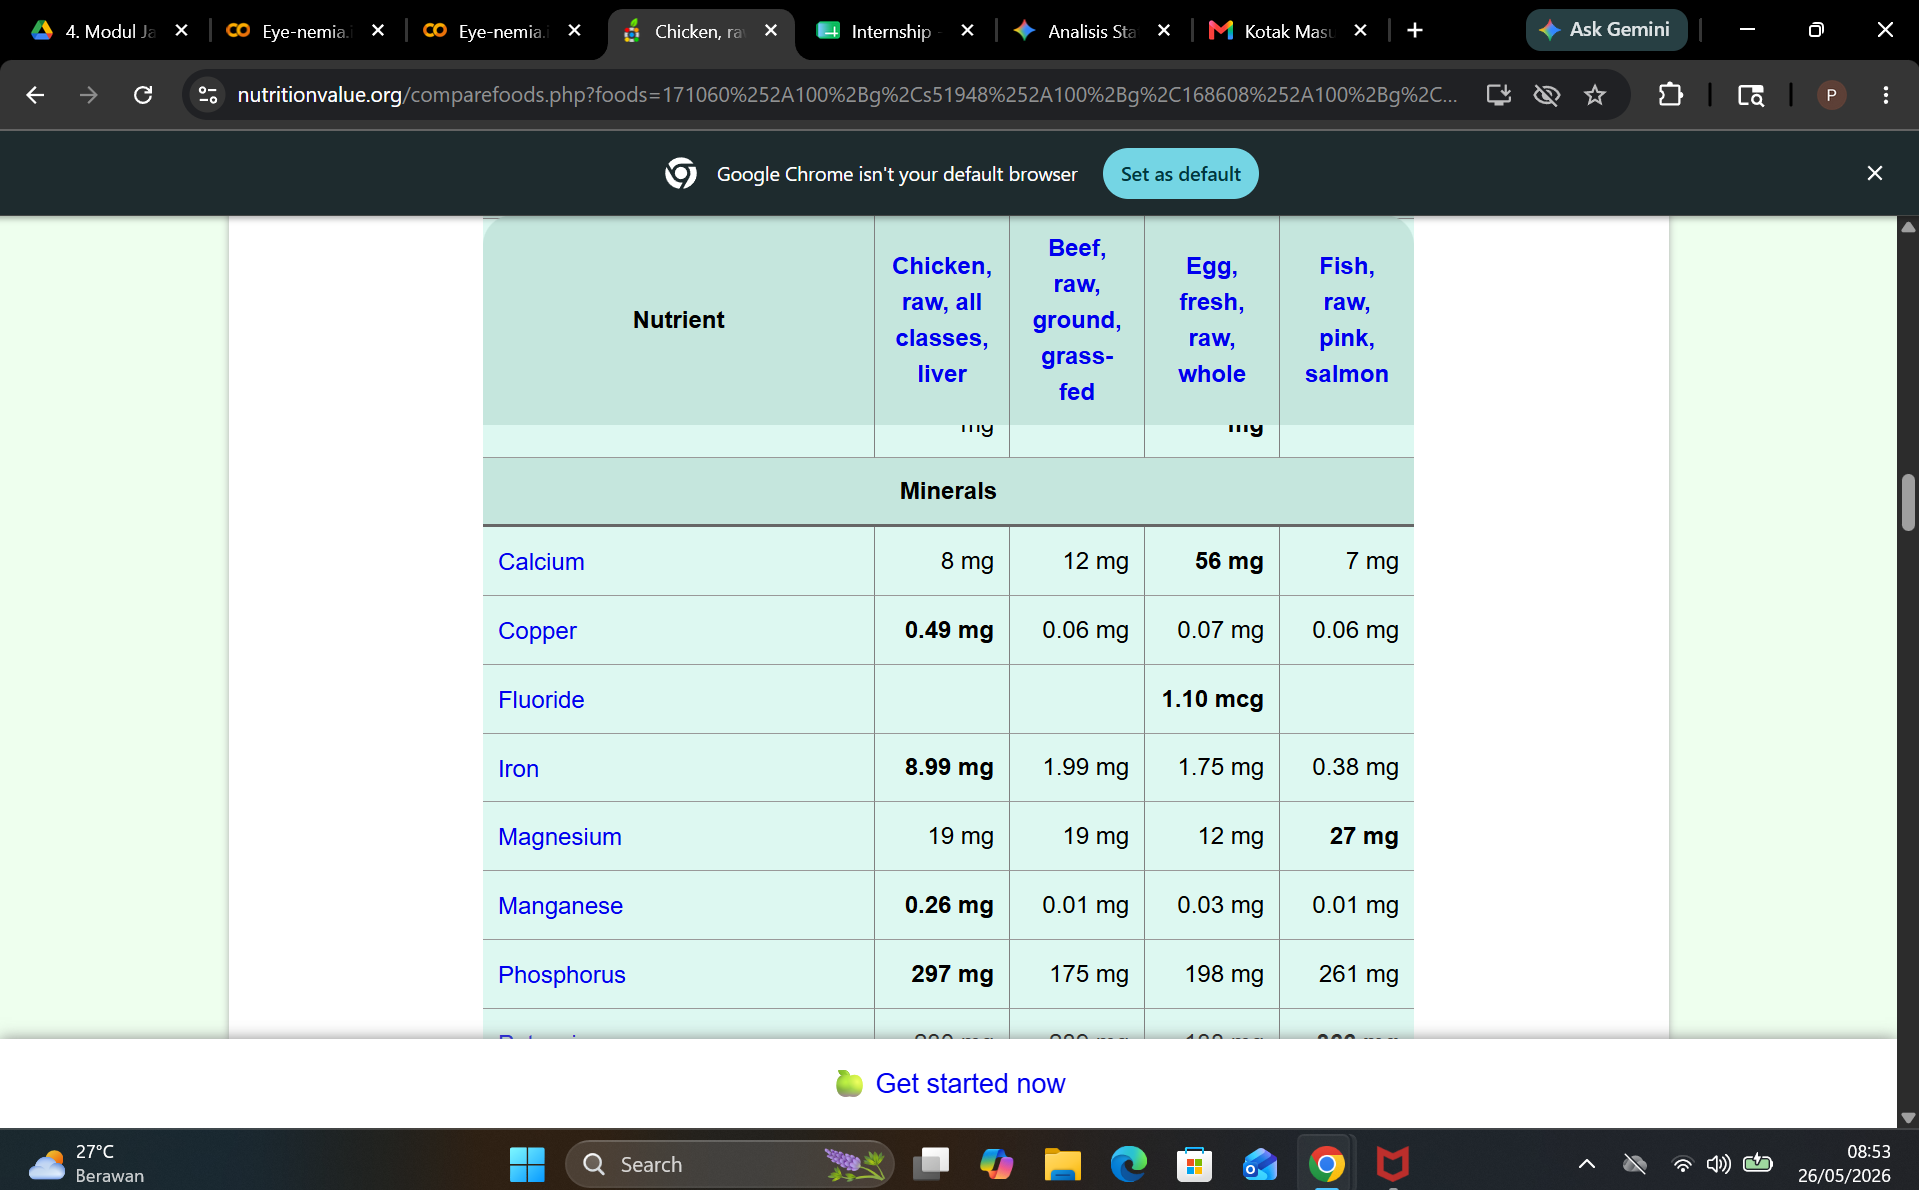**Insight Iron Rich Food Score:**

Fitur `Iron_Rich_Food_Score` dibuat dari akumulasi 4 sumber makanan
utama kaya zat besi hewani (heme iron) dengan pembobotan berdasarkan
kandungan zat besi per 100g (sumber: nutritionvalue.org):

- Hati sapi (`Consume_Liver`)    : bobot 9.0 mg/100g
- Daging merah (`Consume_RedMeat`): bobot 2.0 mg/100g
- Telur (`Consume_Egg`)          : bobot 1.7 mg/100g
- Ikan/tuna (`Consume_Fish`)     : bobot 0.4 mg/100g

Zat besi hewani (heme iron) dipilih karena penyerapannya oleh tubuh
jauh lebih efektif dibanding zat besi nabati (non-heme), sehingga
lebih representatif dalam menggambarkan asupan zat besi yang
fungsional bagi tubuh.

Berdasarkan hasil statistik deskriptif:
- Rata-rata skor sebesar 20.96 dari maksimum 52.40
- Nilai minimum 0.0 menunjukkan ada pengguna yang sama sekali
  tidak mengonsumsi sumber zat besi hewani
- Semakin rendah `Iron_Rich_Food_Score`, semakin tinggi risiko
  kekurangan zat besi yang dapat memicu anemia

## Membuat fitur iron inhibitor score
Fitur ini merepresentasikan kebiasaan yang menghambat penyerapan zat besi, yaitu konsumsi teh dan kopi setelah makan.

In [111]:
# Teh dan kopi mengandung tanin/kafein yang menghambat absorpsi zat besi
inhibitor_cols = ['Tea_After_Meal', 'Coffee_After_Meal']

df_fe['Iron_Inhibitor_Score'] = df_fe[inhibitor_cols].sum(axis=1)

print('Statistik Iron_Inhibitor_Score:')
print(df_fe['Iron_Inhibitor_Score'].describe().round(2))

Statistik Iron_Inhibitor_Score:
count    17358.00
mean         3.09
std          2.20
min          0.00
25%          1.00
50%          3.00
75%          5.00
max          8.00
Name: Iron_Inhibitor_Score, dtype: float64


**Insight Iron Inhibitor Score**

Fitur `Iron_Inhibitor_Score` dibuat dari akumulasi dua kebiasaan yang
dapat menghambat penyerapan zat besi, yaitu:
- `Tea_After_Meal`
- `Coffee_After_Meal`

Kedua fitur memiliki skala ordinal `0–4`, sehingga skor total memiliki
rentang teoretis `0–8`. Semakin tinggi skor, semakin sering seseorang
mengonsumsi teh atau kopi setelah makan yang berpotensi menghambat
absorpsi zat besi akibat kandungan tanin dan kafein.

Berdasarkan hasil statistik deskriptif:

- Rata-rata skor sebesar `3.09` menunjukkan bahwa kebiasaan konsumsi
  teh atau kopi setelah makan cukup umum ditemukan pada pengguna.

- Median sebesar `3.00` yang sangat dekat dengan mean `3.09`
  menunjukkan distribusi data relatif seimbang tanpa skewness yang
  terlalu ekstrem.

- Nilai minimum `0.00` menunjukkan terdapat pengguna yang sama sekali
  tidak memiliki kebiasaan mengonsumsi teh maupun kopi setelah makan.

- Nilai maksimum `8.00` menunjukkan terdapat pengguna yang sangat
  sering mengonsumsi kedua minuman tersebut setelah makan hingga
  mencapai batas maksimum skor.

- Rentang interquartile (IQR) dari `1.00` hingga `5.00`
  menunjukkan bahwa sebagian besar pengguna memiliki tingkat konsumsi
  inhibitor zat besi pada kategori rendah hingga sedang.

- Standar deviasi sebesar `2.20` mengindikasikan variasi kebiasaan
  konsumsi yang cukup tinggi antar pengguna.

Fitur ini penting karena konsumsi teh dan kopi setelah makan dapat
mengurangi penyerapan zat besi non-heme dalam tubuh. Risiko tersebut
dapat menjadi lebih besar apabila pengguna juga memiliki pola konsumsi
makanan kaya zat besi yang rendah.

## Membuat fitur menstruation risk
Fitur ini merepresentasikan risiko anemia dari kondisi menstruasi, dengan mempertimbangkan durasi dan volume darah yang dikeluarkan.

In [112]:
# Skor risiko: gabungan durasi (bobot 0.5) + volume darah (bobot 0.5)
df_fe['Menstruation_Risk'] = (df_fe['Menstruation_Days'] /13 * 0.5) + \
                              (df_fe['Menstrual_Blood_Volume'] / 3 * 0.5)

df_fe['Menstruation_Risk'] = df_fe['Menstruation_Risk'].round(4)

print('Statistik Menstruation_Risk:')
print(df_fe['Menstruation_Risk'].describe().round(4))

Statistik Menstruation_Risk:
count    17358.0000
mean         0.3741
std          0.2418
min          0.0000
25%          0.1154
50%          0.3333
75%          0.5641
max          1.0000
Name: Menstruation_Risk, dtype: float64


**Insight `Menstruation_Risk` (Logika & Statistik)**

Fitur baru `Menstruation_Risk` diciptakan untuk merangkum risiko kehilangan darah bulanan responden menjadi satu metrik yang padu. Berdasarkan proses perumusan matematika dan hasil statistik deskriptifnya, berikut adalah insight komprehensif dari fitur ini:

**1. Logika Pembobotan yang Adil (Fairness via Normalization)**
Sebelum digabungkan, kedua variabel asal dinormalisasi terlebih dahulu ke skala 0 - 1 (`Menstruation_Days` dibagi 13 dan `Menstrual_Blood_Volume` dibagi 3). Dengan pembobotan seimbang (50:50), model kini melihat durasi haid dan volume darah secara setara. Wanita dengan haid singkat namun volume darah sangat banyak akan terhitung memiliki skor risiko yang adil jika dibandingkan dengan wanita berhaid lama namun volume darahnya sedikit.

**2. Bukti Keberhasilan Skala (Berdasarkan Statistik)**
Melihat hasil `.describe()`, nilai minimum fitur ini adalah tepat **0.0000** dan nilai maksimumnya tepat **1.0000**. Hal ini membuktikan bahwa proses normalisasi skala berhasil sempurna. Rentang nilai 0.0 hingga 1.0 ini sangat ideal dan ramah bagi arsitektur pembobotan (*weights*) pada model Deep Learning/Neural Network.

**3. Distribusi yang Realistis Secara Medis**
* **Rata-rata (Mean): 0.3741**
* **Nilai Tengah (Median/50%): 0.3333**
Fakta bahwa rata-rata risiko berada di bawah 0.5 (di bawah setengah skala) sangat masuk akal secara biologis. Ini merepresentasikan bahwa mayoritas responden wanita dalam dataset memiliki siklus haid dan volume kehilangan darah yang normal. Hanya kelompok minoritas (kuartil atas / 75%) yang menembus skor di atas 0.5641 hingga mendekati batas maksimum risiko (1.0).

**Kesimpulan & Implikasi Pemodelan:**
Fitur `Menstruation_Risk` berhasil menerjemahkan logika medis ke dalam format matematis yang solid. Daripada membiarkan model menebak hubungan antara durasi dan volume darah secara terpisah, metrik gabungan ini akan bertindak sebagai **strong predictor** (sinyal kuat) pendeteksi Anemia.

*Tindakan Lanjutan:* Untuk mengurangi dimensi data (*dimensionality reduction*), Anda sangat disarankan untuk men-*drop* (menghapus) kolom asli `Menstruation_Days` dan `Menstrual_Blood_Volume` pada tahap berikutnya, karena seluruh informasi pentingnya sudah terangkum sempurna di dalam fitur baru ini.

## Membuat fitur poor diet score
Fitur ini merepresentasikan kombinasi pola makan buruk yang secara tidak langsung berkontribusi terhadap risiko anemia.

In [113]:
# Junk food tinggi + tidak sarapan + jarang sayur hijau + jarang buah vit C
# Eat_Breakfast sudah binary: 1=Ya, 0=Tidak → diinvert agar 1=buruk

df_fe['Poor_Diet_Score'] = (
    df_fe['Junk_Food_Frequency'] +        # 0-4, lebih tinggi = lebih buruk
    (1 - df_fe['Eat_Breakfast']) * 4 +    # tidak sarapan → skor max 4
    (4 - df_fe['Consume_GreenVeg']) +     # jarang sayur hijau
    (4 - df_fe['Consume_FruitVitC'])      # jarang buah vit C
)

print('Statistik Poor_Diet_Score:')
print(df_fe['Poor_Diet_Score'].describe().round(2))

Statistik Poor_Diet_Score:
count    17358.00
mean         8.49
std          4.48
min          0.00
25%          4.00
50%          9.00
75%         13.00
max         16.00
Name: Poor_Diet_Score, dtype: float64


**Insight Poor Diet Score**

Fitur `Poor_Diet_Score` dibuat untuk merepresentasikan tingkat pola
makan buruk berdasarkan kombinasi empat kebiasaan utama, yaitu:
- Tingginya konsumsi junk food (`Junk_Food_Frequency`)
- Tidak sarapan (`Eat_Breakfast`)
- Rendahnya konsumsi sayuran hijau (`Consume_GreenVeg`)
- Rendahnya konsumsi buah sumber vitamin C (`Consume_FruitVitC`)

Beberapa fitur yang awalnya memiliki makna “semakin tinggi semakin baik”
dibalik (inverted) terlebih dahulu agar seluruh komponen memiliki arah
yang konsisten, yaitu:
> semakin tinggi skor → semakin buruk pola makan.

Fitur ini memiliki rentang teoretis `0–16`.

Berdasarkan hasil statistik deskriptif:

- Rata-rata skor sebesar `8.49` dari maksimum `16`
  menunjukkan bahwa pola makan pengguna secara umum berada pada
  tingkat kurang baik hingga sedang.

- Nilai minimum `0.00` menunjukkan terdapat pengguna dengan pola makan
  sangat baik, yaitu rutin sarapan, jarang mengonsumsi junk food,
  serta sering mengonsumsi sayur hijau dan buah vitamin C.

- Nilai maksimum `16.00` menunjukkan terdapat pengguna dengan pola
  makan sangat buruk pada seluruh komponen sekaligus.

- Median sebesar `9.00` yang cukup dekat dengan mean `8.49`
  menunjukkan distribusi data relatif seimbang tanpa skewness ekstrem.

- Rentang interquartile (IQR) dari `4.00` hingga `13.00`
  menunjukkan variasi pola makan yang cukup besar antar pengguna.

- Standar deviasi sebesar `4.48` mengindikasikan adanya perbedaan
  kebiasaan makan yang cukup signifikan di dalam dataset.

Fitur ini penting karena pola makan yang buruk dapat menyebabkan
rendahnya asupan zat besi dan vitamin C yang dibutuhkan tubuh untuk
mendukung pembentukan hemoglobin serta penyerapan zat besi secara optimal.
Dengan menggabungkan beberapa indikator pola makan ke dalam satu skor,
model machine learning dapat lebih mudah mengenali pengaruh kualitas
pola makan terhadap risiko anemia.

## Verifikasi hasil feature engineering

In [114]:
new_features = [
    'BMI', 'BMI_Category', 'Iron_Rich_Food_Score',
    'Iron_Inhibitor_Score', 'Menstruation_Risk', 'Poor_Diet_Score'
]

print(f'Shape dataset dengan fitur baru: {df_fe.shape}')
print(f'Jumlah fitur baru ditambahkan  : {len(new_features)}')
print()
print('Statistik fitur baru:')
df_fe[new_features].describe().round(2)

Shape dataset dengan fitur baru: (17358, 46)
Jumlah fitur baru ditambahkan  : 6

Statistik fitur baru:


,BMI,BMI_Category,Iron_Rich_Food_Score,Iron_Inhibitor_Score,Menstruation_Risk,Poor_Diet_Score
count,17358.00,17358.00,17358.00,17358.00,17358.00,17358.00
mean,25.13,1.58,20.96,3.09,0.37,8.49
std,6.12,1.00,14.75,2.20,0.24,4.48
min,10.07,0.00,0.00,0.00,0.00,0.00
25%,20.64,1.00,8.40,1.00,0.12,4.00
50%,25.08,2.00,19.70,3.00,0.33,9.00
75%,29.55,2.00,35.20,5.00,0.56,13.00
max,38.34,3.00,52.40,8.00,1.00,16.00


## Insight Verifikasi Hasil Feature Engineering

Proses feature engineering berhasil menambahkan `6 fitur baru`
ke dalam dataset, sehingga ukuran dataset berubah menjadi
`17.358 baris` dan `46 kolom`.

Fitur baru yang ditambahkan meliputi:
- `BMI`
- `BMI_Category`
- `Iron_Rich_Food_Score`
- `Iron_Inhibitor_Score`
- `Menstruation_Risk`
- `Poor_Diet_Score`

Ringkasan karakteristik masing-masing fitur:

- `BMI` memiliki rata-rata `25.13` dengan rentang `10.07–38.34`,
  menunjukkan mayoritas pengguna berada pada kategori normal hingga
  overweight.

- `BMI_Category` memiliki rata-rata `1.58` pada skala ordinal
  `0–3`, yang menunjukkan distribusi pengguna lebih banyak berada
  pada kategori normal dan overweight.

- `Iron_Rich_Food_Score` memiliki rata-rata `20.96`
  dengan rentang `0.00–52.40`, menunjukkan variasi konsumsi makanan
  kaya zat besi yang cukup besar antar pengguna.

- `Iron_Inhibitor_Score` memiliki rata-rata `3.09`
  dengan rentang `0.00–8.00`, menandakan kebiasaan konsumsi teh
  dan kopi setelah makan cukup umum ditemukan pada dataset.

- `Menstruation_Risk` memiliki rata-rata `0.37`
  dengan rentang `0.00–1.00`, menunjukkan tingkat risiko kehilangan
  darah menstruasi yang bervariasi antar pengguna.

- `Poor_Diet_Score` memiliki rata-rata `8.49`
  dengan rentang `0.00–16.00`, mengindikasikan kualitas pola makan
  pengguna secara umum berada pada tingkat kurang baik hingga sedang.

Selain itu, hasil verifikasi menunjukkan seluruh fitur baru berhasil
dibentuk tanpa menghasilkan nilai kosong (`NaN`). Seluruh fitur juga
sudah berada dalam format numerik sehingga dataset siap digunakan
untuk tahap train-test split dan pelatihan model machine learning
maupun deep learning.

## Visualisasi korelasi antara fitur baru terhadap `risk score`

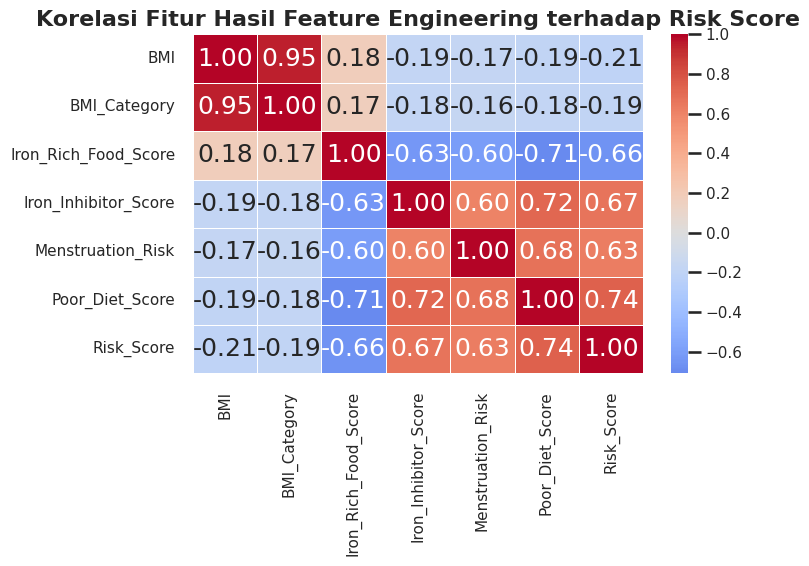

In [115]:
corr_cols = new_features + ['Risk_Score']
corr_matrix = df_fe[corr_cols].corr(method='pearson')

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5
)
plt.title('Korelasi Fitur Hasil Feature Engineering terhadap Risk Score')
plt.tight_layout()
plt.show()

## Insight Korelasi Fitur Hasil Feature Engineering

Heatmap korelasi menunjukkan hubungan antara fitur hasil
feature engineering terhadap target `Risk_Score`.
Beberapa pola penting yang ditemukan adalah sebagai berikut:

- `Poor_Diet_Score` memiliki korelasi positif tertinggi terhadap
  `Risk_Score` sebesar `0.74`. Hal ini menunjukkan bahwa semakin
  buruk pola makan seseorang — seperti sering mengonsumsi junk food,
  tidak sarapan, serta jarang mengonsumsi sayur hijau dan buah vitamin C —
  maka semakin tinggi risiko anemia.

- `Iron_Inhibitor_Score` menunjukkan korelasi positif kuat sebesar
  `0.67` terhadap `Risk_Score`. Temuan ini mengindikasikan bahwa
  kebiasaan mengonsumsi teh atau kopi setelah makan berhubungan
  dengan peningkatan risiko anemia akibat hambatan penyerapan zat besi.

- `Menstruation_Risk` memiliki korelasi positif sebesar `0.52`
  terhadap `Risk_Score`, menunjukkan bahwa durasi menstruasi yang
  lebih panjang dan volume darah yang lebih banyak berkontribusi
  terhadap peningkatan risiko anemia.

- `Iron_Rich_Food_Score` memiliki korelasi negatif kuat sebesar
  `-0.70` terhadap `Risk_Score`. Artinya, semakin baik konsumsi
  makanan kaya zat besi, maka risiko anemia cenderung semakin rendah.

- `BMI` dan `BMI_Category` juga menunjukkan korelasi negatif terhadap
  `Risk_Score`, masing-masing sebesar `-0.21` dan `-0.19`.
  Hal ini menunjukkan bahwa individu dengan BMI lebih rendah
  cenderung memiliki risiko anemia lebih tinggi dibandingkan
  individu dengan BMI normal atau overweight.

Selain hubungan terhadap target, heatmap juga menunjukkan adanya
hubungan antar fitur yang cukup kuat dan logis secara medis, seperti:

- `Poor_Diet_Score` berkorelasi negatif kuat dengan
  `Iron_Rich_Food_Score` (`-0.76`), yang menunjukkan bahwa pola makan
  buruk umumnya diikuti rendahnya konsumsi makanan kaya zat besi.

- `Poor_Diet_Score` berkorelasi positif dengan
  `Iron_Inhibitor_Score` (`0.72`), yang mengindikasikan bahwa
  pengguna dengan pola makan buruk juga cenderung memiliki kebiasaan
  konsumsi teh atau kopi setelah makan.

Meskipun terdapat beberapa korelasi antar fitur, hubungan tersebut
masih relevan secara klinis dan mencerminkan interaksi nyata antar
faktor risiko anemia. Kombinasi fitur-fitur ini diharapkan dapat
membantu model machine learning mengenali pola risiko anemia secara
lebih komprehensif.

In [116]:
df_fe.to_csv('eye_nemia_feature_engineered.csv', index=False)

print('Dataset final berhasil disimpan!')
print(f'Shape final : {df_fe.shape}')
print(f'Fitur baru  : {new_features}')

Dataset final berhasil disimpan!
Shape final : (17358, 46)
Fitur baru  : ['BMI', 'BMI_Category', 'Iron_Rich_Food_Score', 'Iron_Inhibitor_Score', 'Menstruation_Risk', 'Poor_Diet_Score']


# Exploratory Data Analysis (EDA)
Tahap ini bertujuan untuk memahami distribusi data, menemukan anomali tersisa, memetakan korelasi, dan pada akhirnya menjawab Pertanyaan Bisnis yang telah ditetapkan.

## Setup & Pengaturan Visualisasi
## Analisis Univariat (Karakteristik Fitur Tunggal)
   - Distribusi Variabel Target (`Risk_Score`)
   - Distribusi Demografi & Fisik (Usia, BMI, Siklus Menstruasi)
   - Distribusi Fitur Rekayasa & Skor Nutrisi (`Menstruation_Risk`, `Poor_Diet_Score`)
   - Proporsi Kategori Medis Utama & Gejala (Hamil, Konsumsi)
## Analisis Bivariat (Hubungan Fitur terhadap Target)
   - Pengaruh Gejala Klinis (Fatigue, Pale Skin) terhadap Lonjakan Risiko
   - Hubungan Fitur Numerik (Fisik & Nutrisi) terhadap Risiko
   - Dampak Status Kehamilan & Riwayat Penyakit terhadap Risiko Anemia
## Analisis Multivariat & Korelasi
   - Heatmap Korelasi Keseluruhan (Top 15 Prediktor)
   - Analisis Interaksi Antar Fitur
## Data-Driven Insight: Menjawab Pertanyaan Bisnis SMART
   - Top 5 Prediktor Terkuat Pemicu Risiko Anemia
   - Top 3 Faktor Pola Makan Pemicu Risiko Tinggi
   - Faktor Dominan Pemicu Risiko pada Pasien Hamil

In [117]:
df_fe.info()

<class 'pandas.core.frame.DataFrame'>
Index: 17358 entries, 0 to 20065
Data columns (total 46 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Age                        17358 non-null  int64  
 1   Height_cm                  17358 non-null  float64
 2   Weight_kg                  17358 non-null  float64
 3   Currently_Pregnant         17358 non-null  int64  
 4   History_Anemia             17358 non-null  int64  
 5   Family_History_Anemia      17358 non-null  int64  
 6   Menstruation_Days          17358 non-null  int64  
 7   Regular_Menstruation       17358 non-null  int64  
 8   Menstrual_Blood_Volume     17358 non-null  int64  
 9   Consume_RedMeat            17358 non-null  int64  
 10  Consume_Liver              17358 non-null  int64  
 11  Consume_Egg                17358 non-null  int64  
 12  Consume_Fish               17358 non-null  int64  
 13  Consume_GreenVeg           17358 non-null  int64  


In [118]:
df_fe.describe()

,Age,Height_cm,Weight_kg,Currently_Pregnant,History_Anemia,Family_History_Anemia,Menstruation_Days,Regular_Menstruation,Menstrual_Blood_Volume,Consume_RedMeat,...,Symptom_HairLoss,Symptom_Weakness,Symptom_DaytimeSleepiness,Risk_Score,BMI,BMI_Category,Iron_Rich_Food_Score,Iron_Inhibitor_Score,Menstruation_Risk,Poor_Diet_Score
count,17358.000000,17358.000000,17358.000000,17358.000000,17358.000000,17358.000000,17358.000000,17358.000000,17358.000000,17358.000000,...,17358.000000,17358.000000,17358.000000,17358.000000,17358.000000,17358.000000,17358.000000,17358.000000,17358.00000,17358.000000
mean,36.952817,153.442552,58.688900,0.086761,0.511464,0.533011,5.185678,0.925107,1.047644,1.590506,...,1.532838,1.521143,1.546952,53.561643,25.134861,1.580309,20.957098,3.088662,0.37406,8.485540
std,10.951843,8.235578,12.911278,0.281493,0.499883,0.498923,3.351286,0.263227,0.956314,1.274940,...,1.199777,1.248096,1.295558,37.439977,6.124447,1.003696,14.753152,2.199825,0.24184,4.483522
min,15.000000,141.000000,30.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,10.070000,0.000000,0.000000,0.000000,0.00000,0.000000
25%,26.000000,145.000000,49.353125,0.000000,0.000000,0.000000,3.000000,1.000000,0.000000,0.000000,...,1.000000,0.000000,0.000000,16.000000,20.640000,1.000000,8.400000,1.000000,0.11540,4.000000
50%,40.000000,151.000000,58.961378,0.000000,1.000000,1.000000,4.000000,1.000000,1.000000,2.000000,...,1.000000,2.000000,2.000000,56.000000,25.080000,2.000000,19.700000,3.000000,0.33330,9.000000
75%,47.000000,160.000000,68.579249,0.000000,1.000000,1.000000,7.000000,1.000000,2.000000,3.000000,...,2.000000,2.000000,3.000000,93.000000,29.550000,2.000000,35.200000,5.000000,0.56410,13.000000
max,49.000000,174.000000,80.600000,1.000000,1.000000,1.000000,13.000000,1.000000,3.000000,4.000000,...,4.000000,4.000000,4.000000,100.000000,38.340000,3.000000,52.400000,8.000000,1.00000,16.000000


In [119]:
df_fe.head()

,Age,Height_cm,Weight_kg,Currently_Pregnant,History_Anemia,Family_History_Anemia,Menstruation_Days,Regular_Menstruation,Menstrual_Blood_Volume,Consume_RedMeat,...,Symptom_HairLoss,Symptom_Weakness,Symptom_DaytimeSleepiness,Risk_Score,BMI,BMI_Category,Iron_Rich_Food_Score,Iron_Inhibitor_Score,Menstruation_Risk,Poor_Diet_Score
0,45,166.0,56.257377,0,0,0,3,1,0,2,...,1,0,0,0,20.42,1,37.7,3,0.1154,2
1,46,152.0,63.988786,0,0,0,3,1,0,2,...,1,0,0,36,27.70,2,28.3,0,0.1154,7
2,16,153.0,42.595274,0,1,1,7,1,3,1,...,1,2,3,6,18.20,0,12.7,4,0.7692,14
3,23,150.0,80.600000,0,0,0,3,1,0,2,...,0,1,0,0,35.82,3,39.0,1,0.1154,3
4,26,147.0,55.747951,0,0,0,3,1,0,2,...,0,0,0,5,25.80,2,46.3,0,0.1154,5


## Setup & Pengaturan Visualisasi EDA

In [120]:
# Setup & Pengaturan Visualisasi EDA

# Mengatur tema dasar seaborn
sns.set_theme(style="whitegrid", context="talk")

# Mengatur palet warna khusus
custom_palette = sns.color_palette("coolwarm", as_cmap=False)
sns.set_palette(custom_palette)

# Mengatur ukuran kanvas default dan resolusi font untuk kualitas presentasi
plt.rcParams.update({
    'figure.figsize': (12, 6),
    'axes.titlesize': 16,
    'axes.titleweight': 'bold',
    'axes.labelsize': 12,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 11,
    'figure.dpi': 100
})

print(f"Total dimensi data siap EDA: {df_fe.shape[0]} Baris, {df_fe.shape[1]} Kolom")

Total dimensi data siap EDA: 17358 Baris, 46 Kolom


## Analisis Univariat

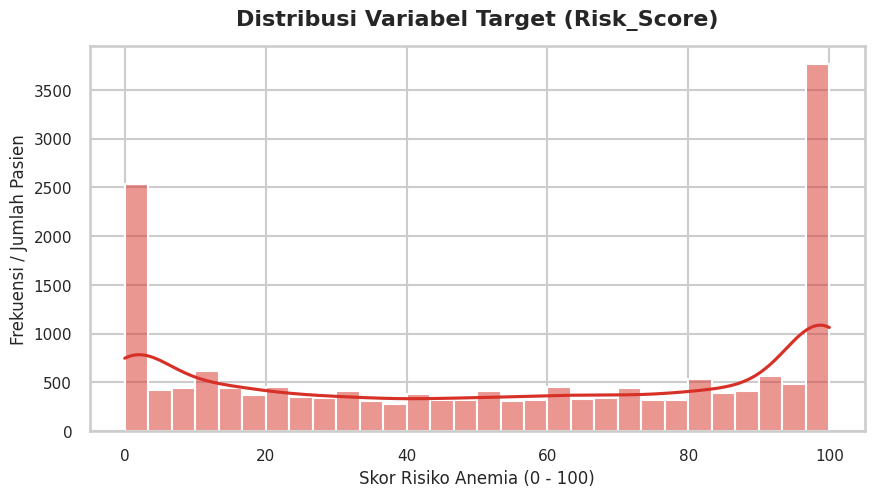

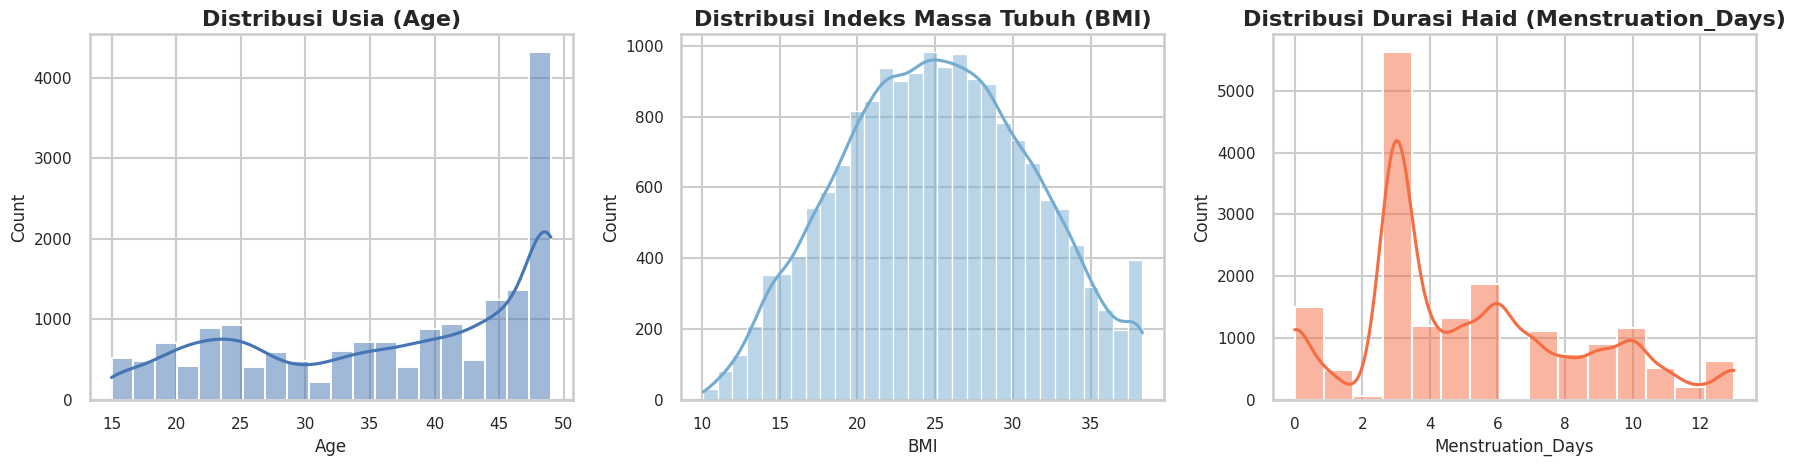

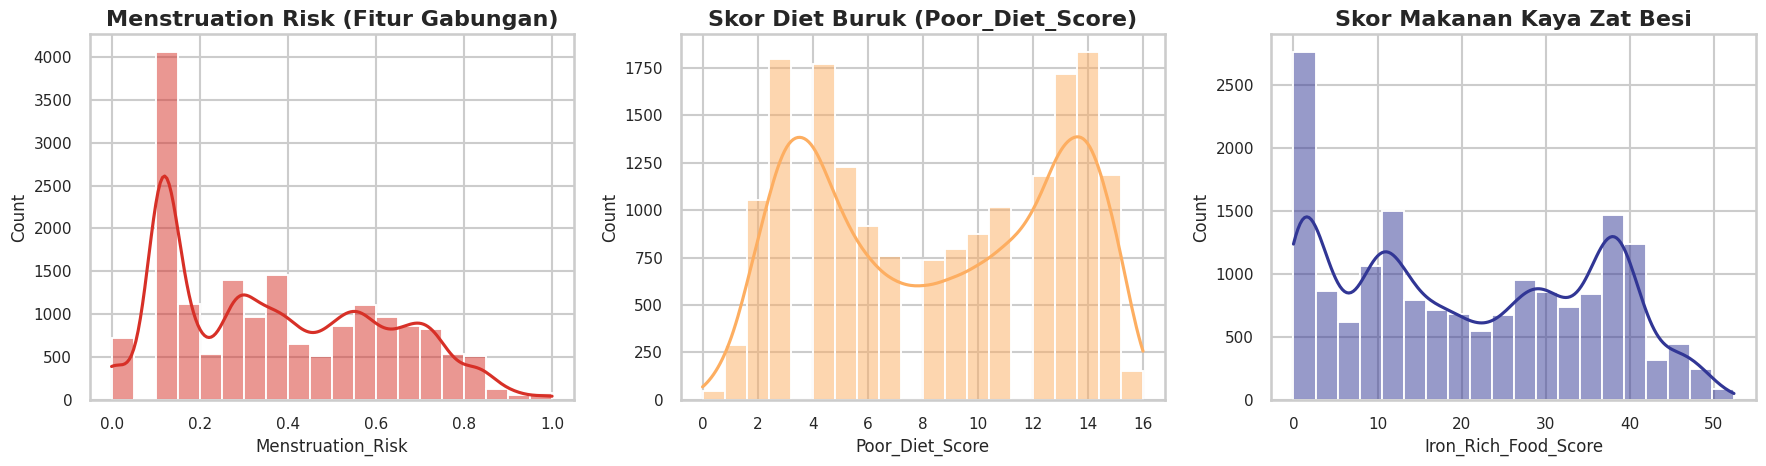

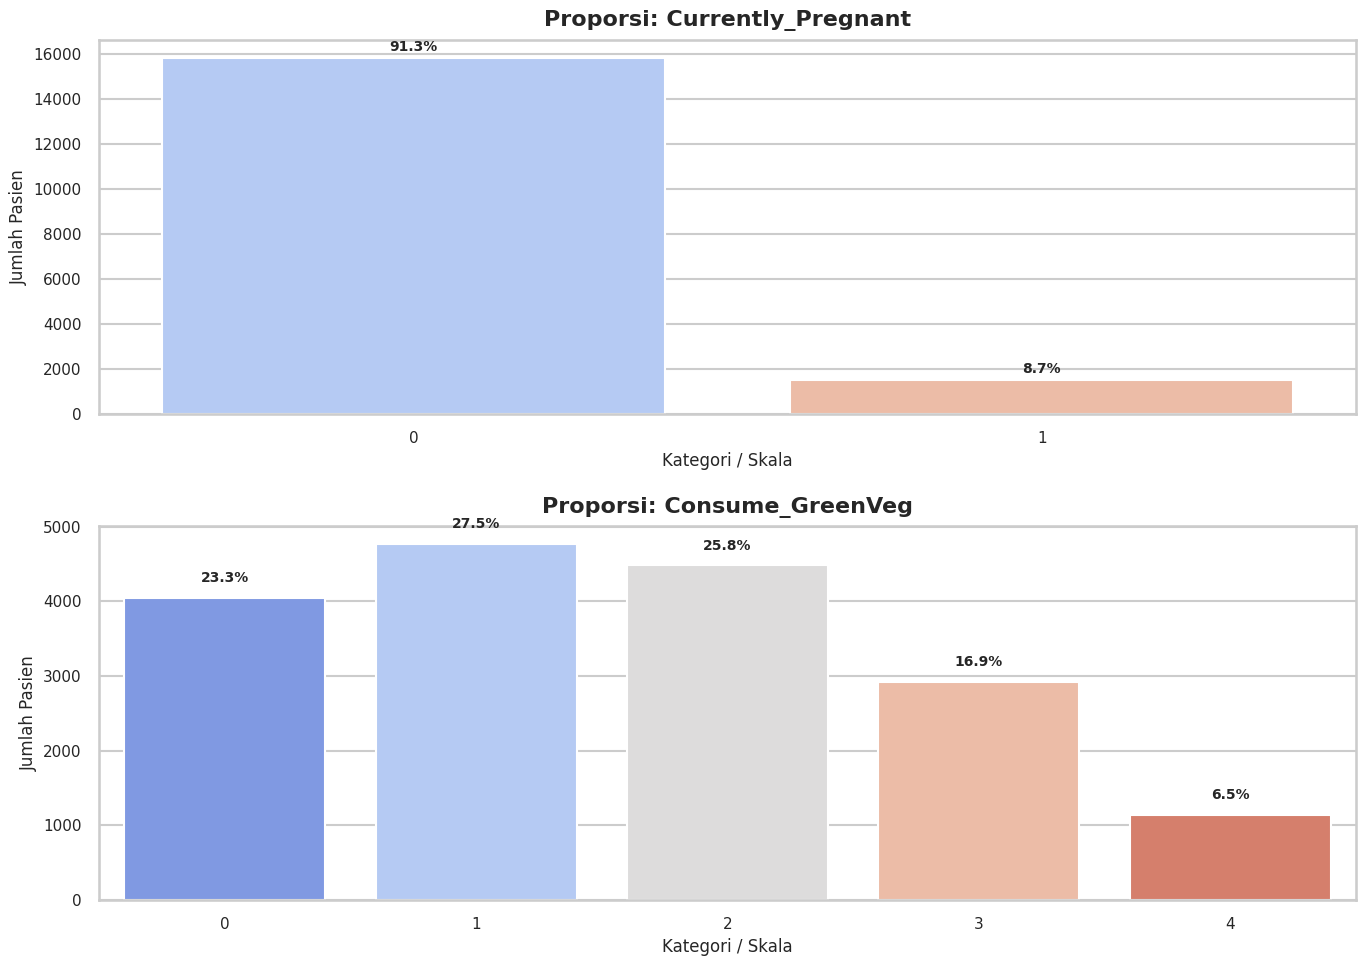

In [121]:
# Distribusi Variabel Target (Risk_Score)

plt.figure(figsize=(10, 5))
sns.histplot(df_fe['Risk_Score'], bins=30, kde=True, color='#d73027')
plt.title('Distribusi Variabel Target (Risk_Score)', pad=15)
plt.xlabel('Skor Risiko Anemia (0 - 100)')
plt.ylabel('Frekuensi / Jumlah Pasien')
plt.show()

# Distribusi Demografi & Fisik
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df_fe['Age'], bins=20, kde=True, ax=axes[0], color='#4575b4')
axes[0].set_title('Distribusi Usia (Age)')

sns.histplot(df_fe['BMI'], bins=30, kde=True, ax=axes[1], color='#74add1')
axes[1].set_title('Distribusi Indeks Massa Tubuh (BMI)')

sns.histplot(df_fe['Menstruation_Days'], bins=15, kde=True, ax=axes[2], color='#f46d43')
axes[2].set_title('Distribusi Durasi Haid (Menstruation_Days)')

plt.tight_layout()
plt.show()

# Distribusi Fitur Rekayasa & Skor Nutrisi
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df_fe['Menstruation_Risk'], bins=20, kde=True, ax=axes[0], color='#d73027')
axes[0].set_title('Menstruation Risk (Fitur Gabungan)')

sns.histplot(df_fe['Poor_Diet_Score'], bins=20, kde=True, ax=axes[1], color='#fdae61')
axes[1].set_title('Skor Diet Buruk (Poor_Diet_Score)')

sns.histplot(df_fe['Iron_Rich_Food_Score'], bins=20, kde=True, ax=axes[2], color='#313695')
axes[2].set_title('Skor Makanan Kaya Zat Besi')

plt.tight_layout()
plt.show()

# Proporsi Kategori Medis Utama & Gejala
fig, axes = plt.subplots(2, 1, figsize=(14, 10))
cat_cols = ['Currently_Pregnant', 'Consume_GreenVeg']
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    ax = sns.countplot(data=df_fe, x=col, ax=axes[i], palette='coolwarm')
    axes[i].set_title(f'Proporsi: {col}', pad=10)
    axes[i].set_ylabel('Jumlah Pasien')
    axes[i].set_xlabel('Kategori / Skala')

    # Menambahkan anotasi persentase di atas bar
    total = len(df_fe[col])
    for p in ax.patches:
        height = p.get_height()
        if height > 0:
            percentage = f'{100 * height / total:.1f}%'
            x = p.get_x() + p.get_width() / 2
            y = height + (total * 0.01)
            ax.annotate(percentage, (x, y), ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

##Analisis Bivariat

Menyiapkan Visualisasi Bivariat (Gejala vs Risiko)...


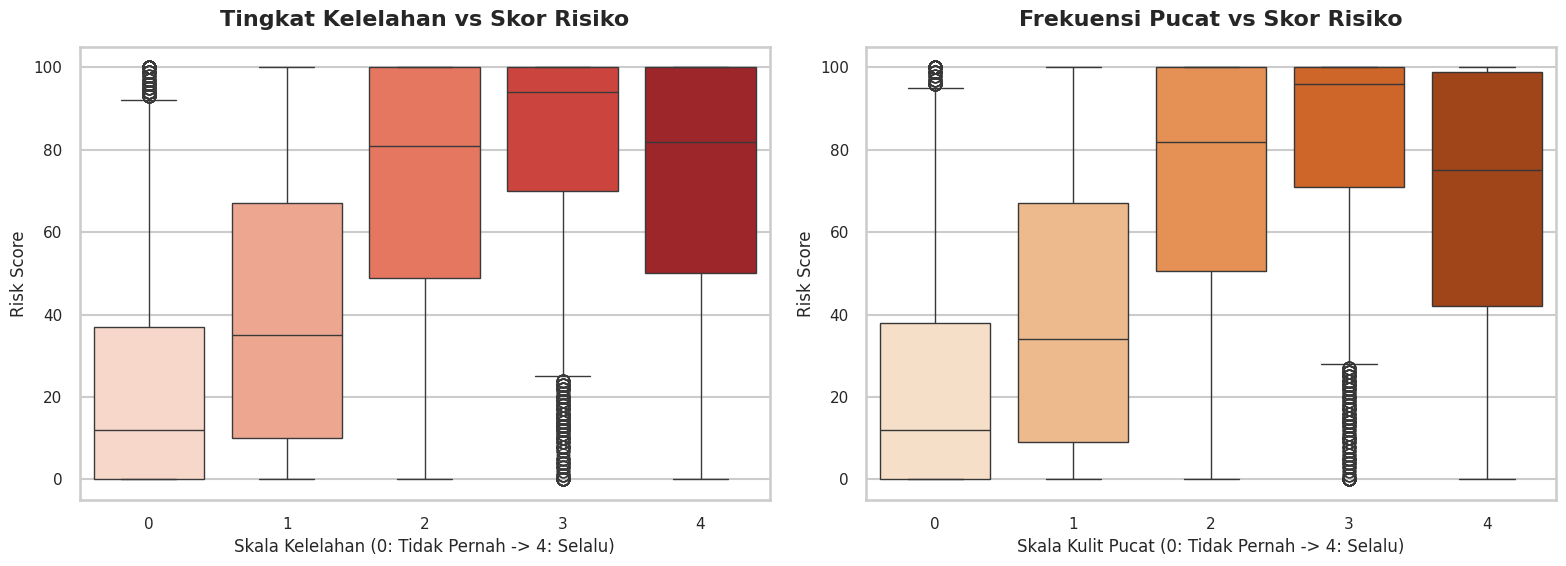


Menyiapkan Visualisasi Bivariat (Fisik & Nutrisi vs Risiko)...


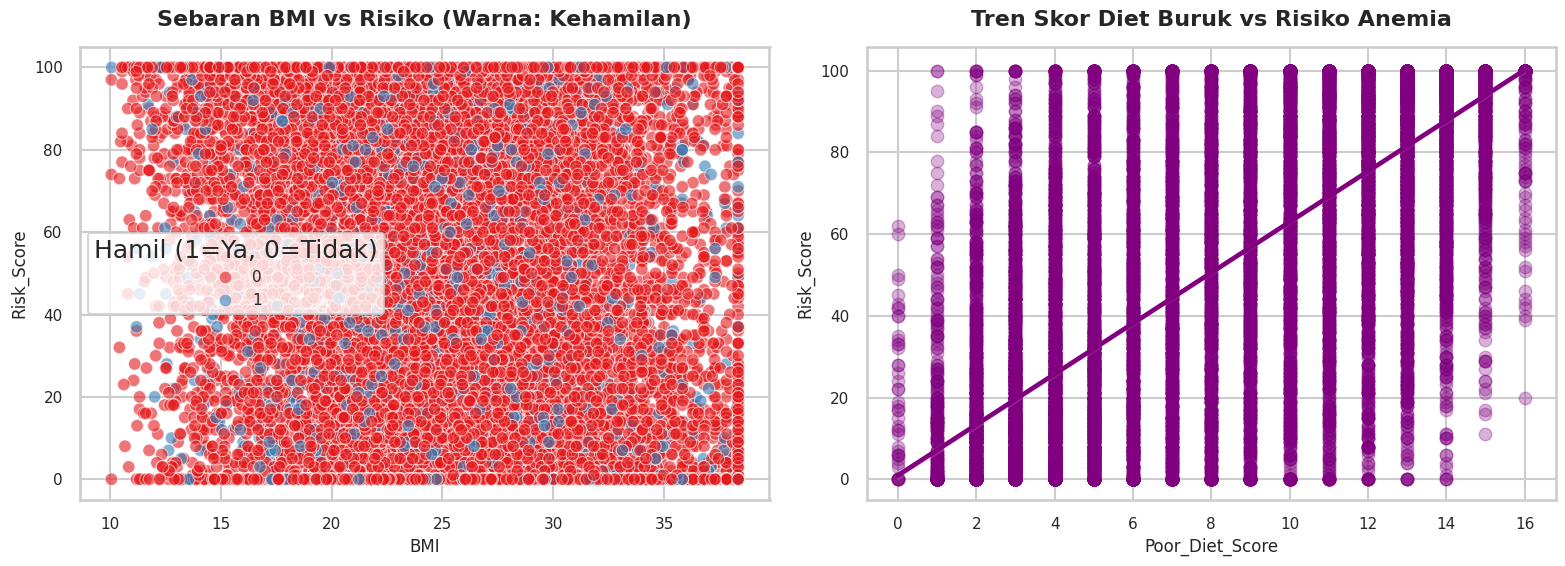


Menyiapkan Visualisasi Bivariat (Kondisi Medis vs Risiko)...


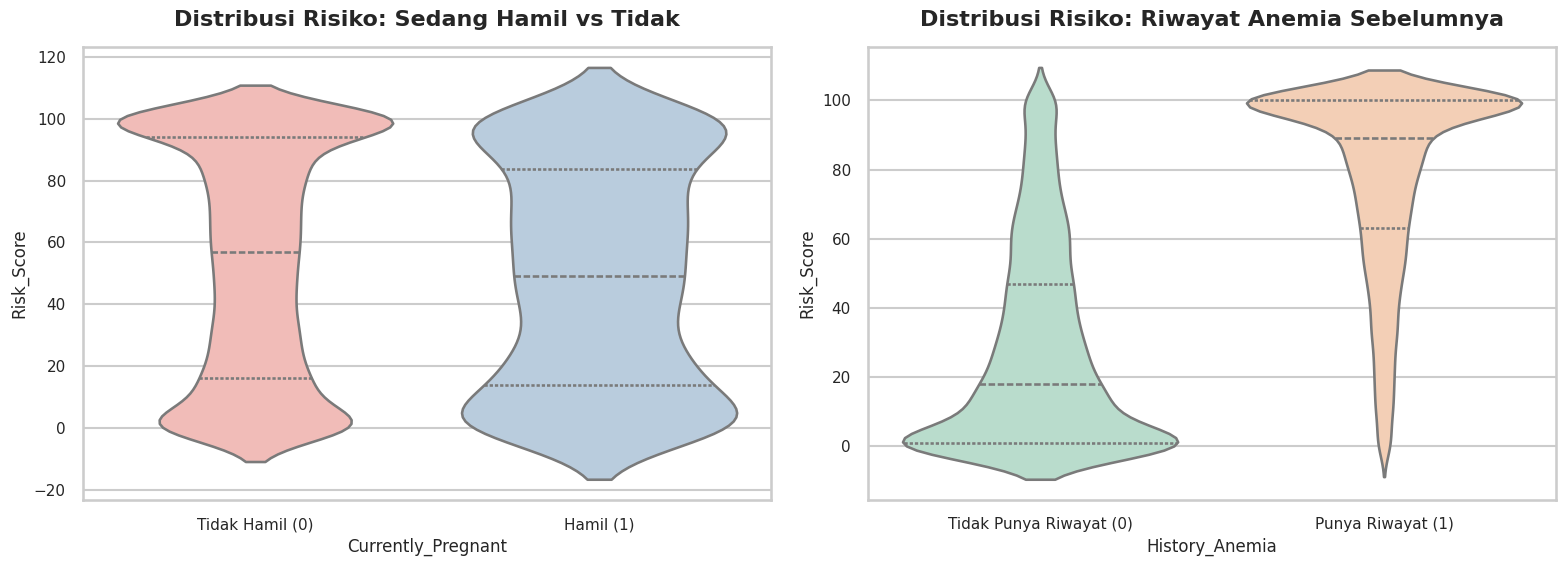

In [122]:
# Pengaruh Gejala Klinis terhadap Lonjakan Risiko
print("Menyiapkan Visualisasi Bivariat (Gejala vs Risiko)...")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Boxplot Gejala Kelelahan
sns.boxplot(data=df_fe, x='Symptom_Fatigue', y='Risk_Score', ax=axes[0], palette='Reds')
axes[0].set_title('Tingkat Kelelahan vs Skor Risiko', pad=15)
axes[0].set_xlabel('Skala Kelelahan (0: Tidak Pernah -> 4: Selalu)')
axes[0].set_ylabel('Risk Score')

# Boxplot Pucat
sns.boxplot(data=df_fe, x='Symptom_PaleSkin', y='Risk_Score', ax=axes[1], palette='Oranges')
axes[1].set_title('Frekuensi Pucat vs Skor Risiko', pad=15)
axes[1].set_xlabel('Skala Kulit Pucat (0: Tidak Pernah -> 4: Selalu)')
axes[1].set_ylabel('Risk Score')

plt.tight_layout()
plt.show()

# Hubungan Fitur Numerik (Fisik & Nutrisi) terhadap Risiko
print("\nMenyiapkan Visualisasi Bivariat (Fisik & Nutrisi vs Risiko)...")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter Plot BMI dengan Hue Kehamilan
sns.scatterplot(data=df_fe, x='BMI', y='Risk_Score', hue='Currently_Pregnant', palette='Set1', alpha=0.6, ax=axes[0])
axes[0].set_title('Sebaran BMI vs Risiko (Warna: Kehamilan)', pad=15)
axes[0].legend(title='Hamil (1=Ya, 0=Tidak)')

# Regression Plot untuk Skor Diet
sns.regplot(data=df_fe, x='Poor_Diet_Score', y='Risk_Score', ax=axes[1], color='purple', scatter_kws={'alpha':0.3})
axes[1].set_title('Tren Skor Diet Buruk vs Risiko Anemia', pad=15)

plt.tight_layout()
plt.show()

# Dampak Status Kehamilan & Riwayat Penyakit
print("\nMenyiapkan Visualisasi Bivariat (Kondisi Medis vs Risiko)...")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Violin Plot Kehamilan
sns.violinplot(data=df_fe, x='Currently_Pregnant', y='Risk_Score', ax=axes[0], palette='Pastel1', inner='quartile')
axes[0].set_title('Distribusi Risiko: Sedang Hamil vs Tidak', pad=15)
axes[0].set_xticklabels(['Tidak Hamil (0)', 'Hamil (1)'])

# Violin Plot Riwayat Anemia
sns.violinplot(data=df_fe, x='History_Anemia', y='Risk_Score', ax=axes[1], palette='Pastel2', inner='quartile')
axes[1].set_title('Distribusi Risiko: Riwayat Anemia Sebelumnya', pad=15)
axes[1].set_xticklabels(['Tidak Punya Riwayat (0)', 'Punya Riwayat (1)'])

plt.tight_layout()
plt.show()

## Analisis Multivariat & Korelasi

In [123]:
# 1. Fungsi Cramer's V (Kategorikal vs Kategorikal)
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = ss.chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape

    # Koreksi bias (Bias correction)
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)

    if min((kcorr-1), (rcorr-1)) == 0:
        return 0
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

# 2. Fungsi Correlation Ratio (Kategorikal vs Numerik)
def correlation_ratio(categories, measurements):
    fcat, _ = pd.factorize(categories)
    cat_num = np.max(fcat)+1
    y_avg_array = np.zeros(cat_num)
    n_array = np.zeros(cat_num)
    for i in range(0,cat_num):
        cat_measures = measurements[np.argwhere(fcat == i).flatten()]
        n_array[i] = len(cat_measures)
        y_avg_array[i] = np.average(cat_measures)
    y_total_avg = np.sum(np.multiply(y_avg_array,n_array))/np.sum(n_array)
    numerator = np.sum(np.multiply(n_array,np.power(np.subtract(y_avg_array,y_total_avg),2)))
    denominator = np.sum(np.power(np.subtract(measurements,y_total_avg),2))
    if numerator == 0:
        eta = 0.0
    else:
        eta = np.sqrt(numerator/denominator)
    return eta

In [143]:
# Buat DataFrame kosong untuk matriks korelasi
all_cols = df_fe.columns
corr_matrix = pd.DataFrame(index=all_cols, columns=all_cols)
num_cols = df_fe.select_dtypes(include=['float64', 'int64']).columns.tolist()
cat_cols = df_fe.select_dtypes(include=['object', 'category']).columns.tolist()

# Drop NA untuk keperluan kalkulasi korelasi murni
df_corr = df_fe.dropna()

for i in range(len(all_cols)):
    for j in range(len(all_cols)):
        col1 = all_cols[i]
        col2 = all_cols[j]

        # Jika kolom yang sama (diagonal matriks)
        if i == j:
            corr_matrix.loc[col1, col2] = 1.0

        # Jika Numerik vs Numerik -> Spearman Rank
        elif col1 in num_cols and col2 in num_cols:
            corr_matrix.loc[col1, col2] = df_corr[col1].corr(df_corr[col2], method='pearson')

        # Jika Kategorikal vs Kategorikal -> Cramer's V
        elif col1 in cat_cols and col2 in cat_cols:
            corr_matrix.loc[col1, col2] = cramers_v(df_corr[col1], df_corr[col2])

        # Jika Kategorikal vs Numerik -> Correlation Ratio (Eta)
        elif col1 in cat_cols and col2 in num_cols:
            corr_matrix.loc[col1, col2] = correlation_ratio(df_corr[col1], df_corr[col2])

        # Jika Numerik vs Kategorikal (Sama dengan di atas)
        elif col1 in num_cols and col2 in cat_cols:
            corr_matrix.loc[col1, col2] = correlation_ratio(df_corr[col2], df_corr[col1])

# Pastikan tipe data float
corr_matrix = corr_matrix.astype(float)

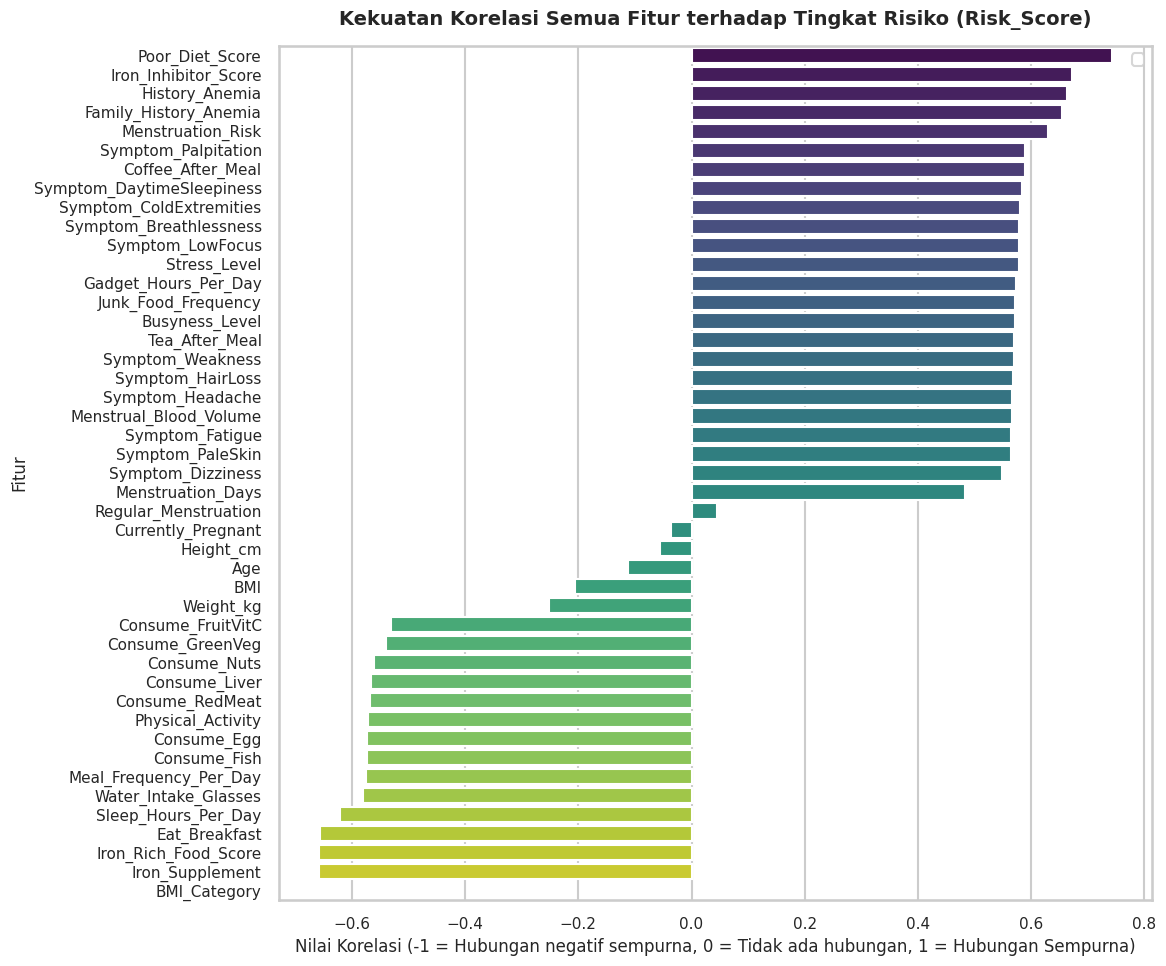

In [144]:
# Ambil korelasi hanya terhadap kolom 'Risk_Score'
target_corr = corr_matrix[['Risk_Score']].drop('Risk_Score')
target_corr = target_corr.sort_values(by='Risk_Score', ascending=False)

# Visualisasi Barplot
plt.figure(figsize=(12, 10))
sns.barplot(x=target_corr['Risk_Score'], y=target_corr.index, palette='viridis')
plt.title('Kekuatan Korelasi Semua Fitur terhadap Tingkat Risiko (Risk_Score)', fontsize=14, pad=15)
plt.xlabel('Nilai Korelasi (-1 = Hubungan negatif sempurna, 0 = Tidak ada hubungan, 1 = Hubungan Sempurna)', fontsize=12)
plt.ylabel('Fitur', fontsize=12)
# plt.axvline(x=0.1, color='red', linestyle='--', alpha=0.5, label='Batas Lemah (<0.1)')
plt.legend()
plt.tight_layout()

# plt.savefig('Korelasi_Risk_Score.png')
plt.show()

**Insight Kekuatan Korelasi Semua Fitur terhadap Risk_Score**

Visualisasi korelasi menunjukkan tingkat hubungan masing-masing fitur
terhadap target `Risk_Score`. Nilai korelasi positif menunjukkan bahwa
semakin tinggi nilai fitur, semakin tinggi risiko anemia, sedangkan
korelasi negatif menunjukkan hubungan sebaliknya.

Beberapa temuan penting dari hasil analisis:

1. Fitur dengan korelasi positif terkuat
- `Poor_Diet_Score` memiliki korelasi positif tertinggi terhadap
  `Risk_Score`. Hal ini menunjukkan bahwa pola makan buruk seperti
  sering mengonsumsi junk food, tidak sarapan, serta rendahnya konsumsi
  sayur dan buah berkaitan kuat dengan peningkatan risiko anemia.

- `Iron_Inhibitor_Score` juga menunjukkan korelasi positif yang kuat,
  mengindikasikan bahwa kebiasaan mengonsumsi teh atau kopi setelah makan
  dapat meningkatkan risiko anemia akibat hambatan penyerapan zat besi.

- `History_Anemia` dan `Family_History_Anemia` memiliki korelasi positif
  tinggi, menunjukkan bahwa riwayat anemia pribadi maupun keluarga
  merupakan faktor risiko penting dalam dataset.

- Berbagai fitur gejala seperti:
  - `Symptom_Palpitation`
  - `Symptom_DaytimeSleepiness`
  - `Symptom_ColdExtremities`
  - `Symptom_Breathlessness`
  - `Symptom_LowFocus`

  juga menunjukkan korelasi positif yang cukup kuat terhadap
  `Risk_Score`, yang berarti semakin sering gejala dirasakan,
  semakin tinggi tingkat risiko anemia.

2. Fitur dengan korelasi negatif terkuat
- `Iron_Rich_Food_Score` memiliki korelasi negatif paling kuat terhadap
  `Risk_Score`. Hal ini menunjukkan bahwa konsumsi makanan kaya zat besi
  berperan protektif dalam menurunkan risiko anemia.

- Konsumsi makanan bergizi seperti:
  - `Consume_RedMeat`
  - `Consume_Liver`
  - `Consume_GreenVeg`
  - `Consume_FruitVitC`
  - `Consume_Fish`
  - `Consume_Egg`

  juga menunjukkan korelasi negatif yang cukup besar terhadap risiko,
  mengindikasikan bahwa pola makan sehat berkaitan dengan risiko anemia
  yang lebih rendah.

- `Sleep_Hours_Per_Day`, `Water_Intake_Glasses`, dan `Physical_Activity`
  turut menunjukkan korelasi negatif moderat, yang menandakan gaya hidup
  sehat cenderung berkaitan dengan kondisi tubuh yang lebih baik dan
  risiko anemia yang lebih rendah.

Kesimpulan Umum

Hasil korelasi menunjukkan bahwa risiko anemia dalam dataset bersifat
multifaktorial dan dipengaruhi kombinasi berbagai aspek, seperti:
- pola makan,
- kebiasaan konsumsi,
- kondisi menstruasi,
- riwayat kesehatan,
- gejala fisik,
- serta gaya hidup pengguna.

Fitur hasil feature engineering seperti `Poor_Diet_Score`,
`Iron_Rich_Food_Score`, dan `Iron_Inhibitor_Score`
terbukti memiliki hubungan yang kuat terhadap target, sehingga
diperkirakan akan memberikan kontribusi penting dalam proses
pelatihan model machine learning maupun deep learning.

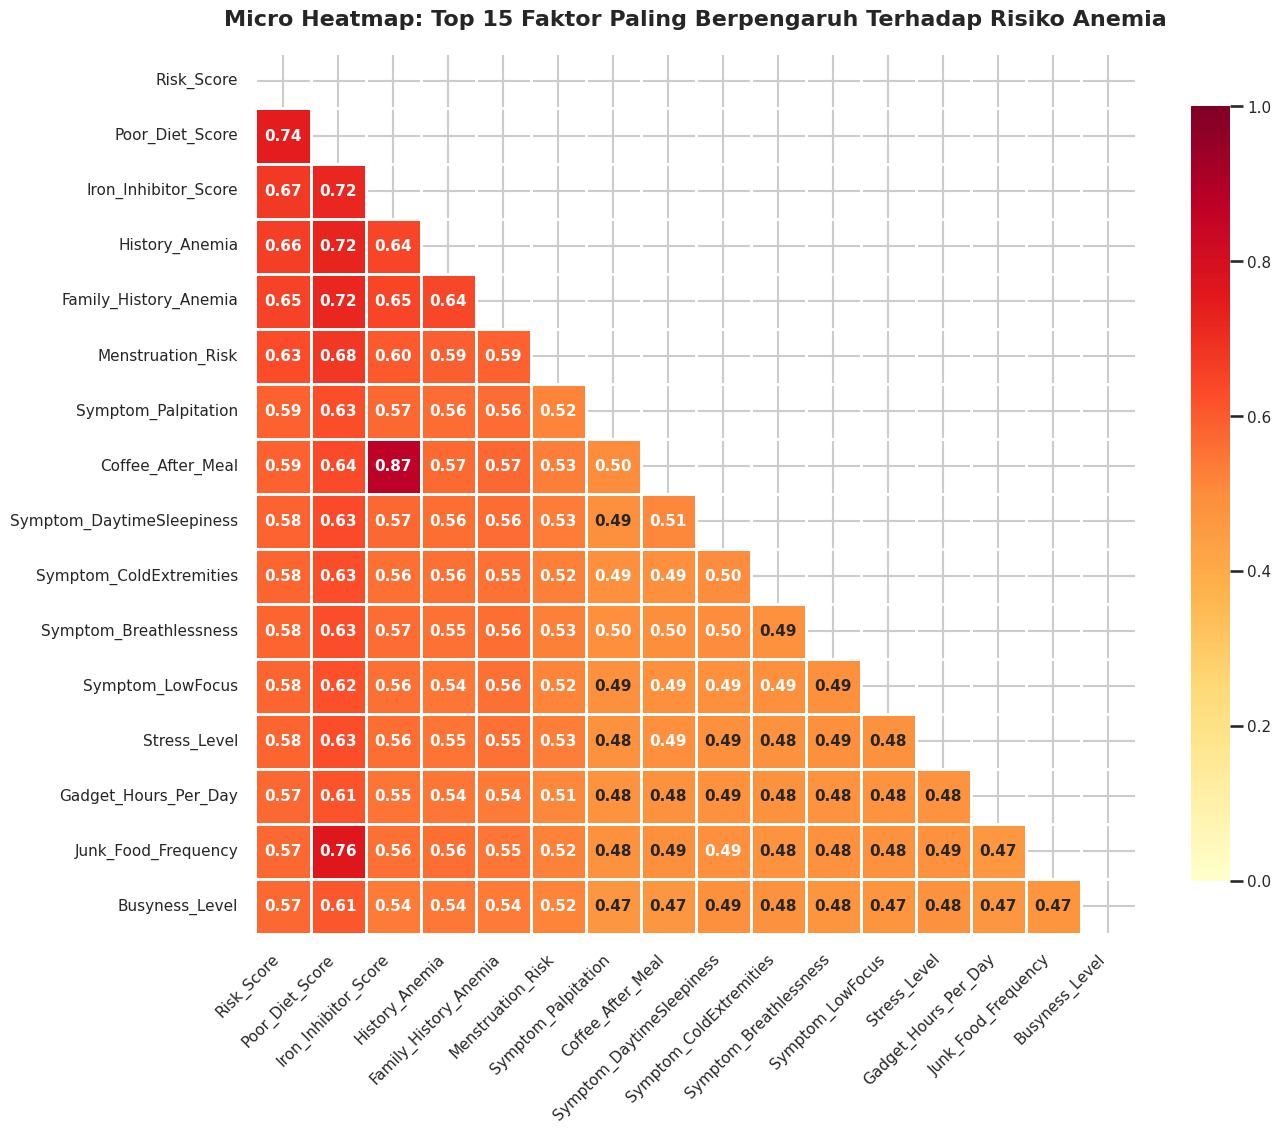

In [145]:
# 1. Ambil korelasi hanya terhadap 'Risk_Score'
target_corr = corr_matrix[['Risk_Score']].drop('Risk_Score')

# 2. Urutkan dari yang paling kuat ke paling lemah, dan ambil 15 teratas
top_15_features = target_corr.sort_values(by='Risk_Score', ascending=False).head(15).index.tolist()

# 3. Masukkan 'Risk_Score' ke dalam list untuk membuat matriks kecil
top_features_list = ['Risk_Score'] + top_15_features

# 4. Potong matriks korelasi hanya untuk fitur-fitur teratas ini
micro_corr_matrix = corr_matrix.loc[top_features_list, top_features_list]

# 5. Visualisasikan Micro Heatmap
plt.figure(figsize=(14, 12))

# Masking segitiga atas untuk Micro Heatmap
micro_mask = np.triu(np.ones_like(micro_corr_matrix, dtype=bool))

sns.heatmap(micro_corr_matrix,
            mask=micro_mask,
            cmap='YlOrRd',
            vmax=1.0,
            vmin=0.0,
            square=True,
            linewidths=1,
            annot=True,     # Nyalakan angka! (Karena ukurannya sekarang kecil, jadi bisa dibaca)
            fmt=".2f",      # 2 angka di belakang koma
            annot_kws={"size": 11, "weight": "bold"},
            cbar_kws={"shrink": .8})

plt.title('Micro Heatmap: Top 15 Faktor Paling Berpengaruh Terhadap Risiko Anemia', fontsize=16, pad=20, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(rotation=0, fontsize=11)
plt.tight_layout()
plt.show()

**Insight Micro Heatmap Top 15 Fitur terhadap Risk_Score**

Micro heatmap menampilkan 15 fitur dengan korelasi paling kuat
terhadap `Risk_Score`. Visualisasi ini membantu mengidentifikasi
faktor-faktor yang paling berpengaruh terhadap risiko anemia
serta hubungan antar fitur penting di dalam dataset.

1. Faktor dengan korelasi tertinggi terhadap Risk_Score

- `Poor_Diet_Score` memiliki korelasi tertinggi terhadap
  `Risk_Score` sebesar `0.74`. Hal ini menunjukkan bahwa pola
  makan buruk merupakan faktor yang sangat berpengaruh terhadap
  peningkatan risiko anemia.

- `Iron_Inhibitor_Score` memiliki korelasi positif kuat sebesar
  `0.67`, yang mengindikasikan bahwa kebiasaan mengonsumsi teh
  atau kopi setelah makan berkaitan dengan meningkatnya risiko
  anemia akibat hambatan penyerapan zat besi.

- `History_Anemia` (`0.66`) dan `Family_History_Anemia` (`0.65`)
  juga menunjukkan hubungan yang kuat terhadap `Risk_Score`,
  menandakan bahwa riwayat anemia pribadi maupun keluarga
  merupakan faktor risiko penting.

- Berbagai gejala fisik seperti:
  - `Symptom_Palpitation`
  - `Symptom_DaytimeSleepiness`
  - `Symptom_ColdExtremities`
  - `Symptom_Breathlessness`
  - `Symptom_LowFocus`

  memiliki korelasi positif moderat hingga kuat terhadap
  `Risk_Score`, yang berarti semakin sering gejala dirasakan,
  semakin tinggi tingkat risiko anemia.

2. Hubungan antar fitur penting

Heatmap juga menunjukkan adanya korelasi kuat antar beberapa fitur:

- `Coffee_After_Meal` memiliki korelasi sangat tinggi dengan
  `Iron_Inhibitor_Score` (`0.87`) karena fitur tersebut memang
  menjadi salah satu komponen pembentuk skor inhibitor zat besi.

- `Tea_After_Meal` juga berkorelasi sangat kuat dengan
  `Iron_Inhibitor_Score` (`0.85`) dengan alasan yang sama.

- `Poor_Diet_Score` berkorelasi cukup kuat dengan
  `Iron_Inhibitor_Score` (`0.72`), menunjukkan bahwa pengguna
  dengan pola makan buruk juga cenderung memiliki kebiasaan
  konsumsi teh atau kopi setelah makan.

**Kesimpulan**

Hasil micro heatmap menunjukkan bahwa faktor risiko anemia pada
dataset tidak hanya dipengaruhi satu aspek saja, tetapi merupakan
kombinasi dari:
- pola makan,
- kebiasaan konsumsi,
- riwayat kesehatan,
- kondisi gaya hidup,
- dan gejala fisik.

Fitur hasil feature engineering seperti:
- `Poor_Diet_Score`
- `Iron_Inhibitor_Score`

terbukti memiliki hubungan yang sangat kuat terhadap target,
sehingga diperkirakan akan memberikan kontribusi besar dalam
proses pelatihan model machine learning maupun deep learning.

##Data-Driven Insight: Menjawab Pertanyaan Bisnis SMART

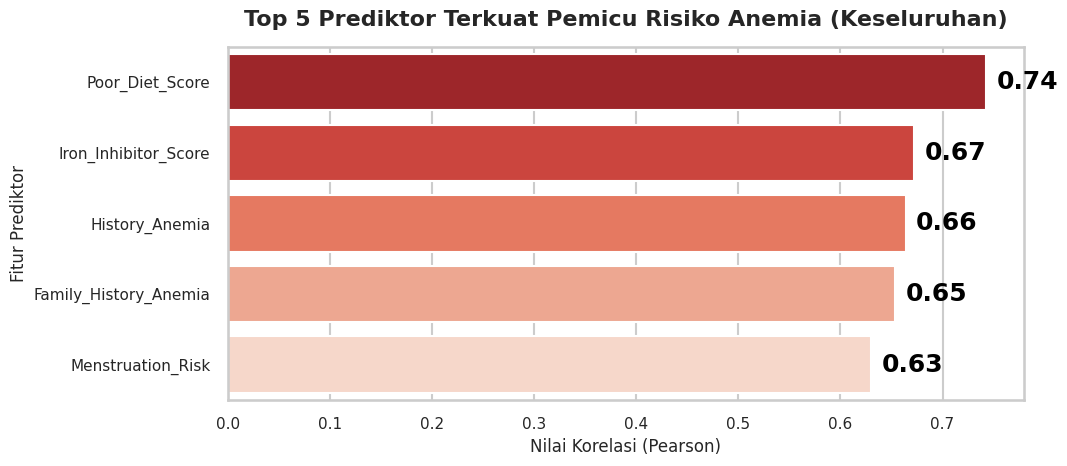

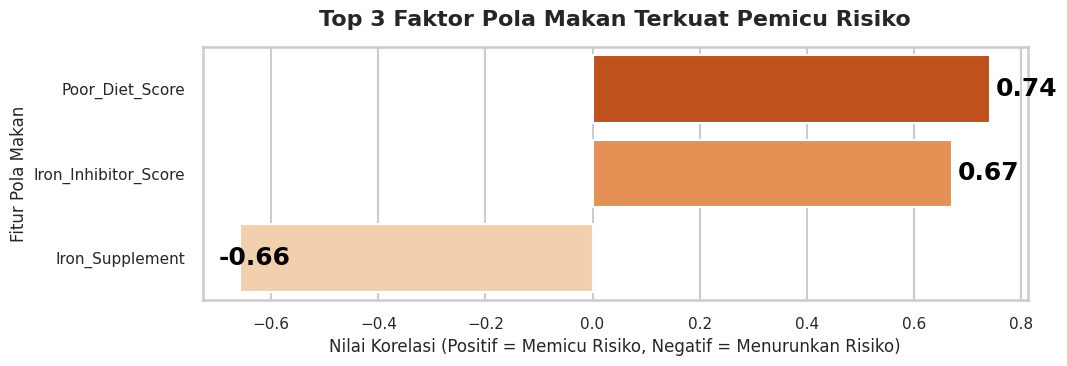

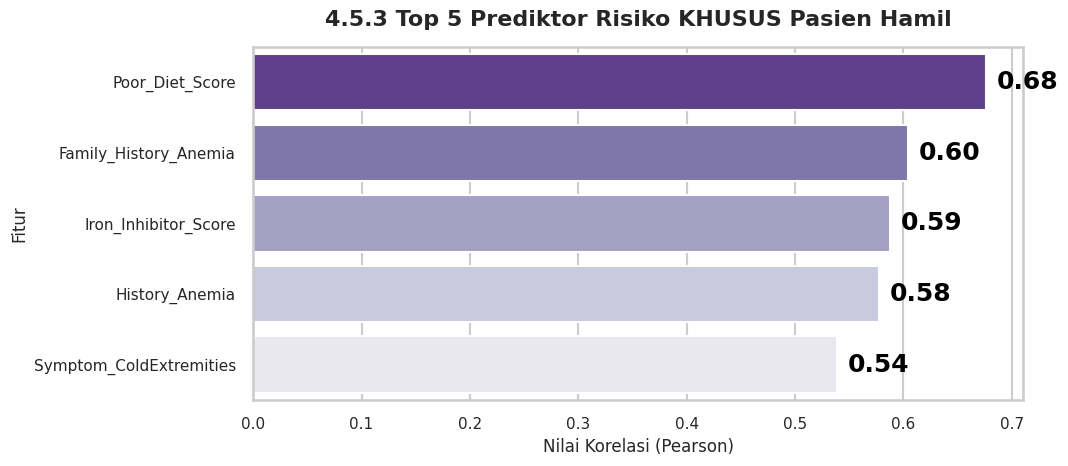

In [146]:
# Data-Driven Insight: Menjawab Pertanyaan Bisnis SMART

numeric_df = df_fe.select_dtypes(include=['int64', 'float64'])

# Top 5 Prediktor Terkuat Pemicu Risiko Anemia
corr_all = numeric_df.corr()['Risk_Score'].drop('Risk_Score').sort_values(ascending=False)
top_5_all = corr_all.head(5)

plt.figure(figsize=(11, 5))
sns.barplot(x=top_5_all.values, y=top_5_all.index, palette='Reds_r')
plt.title('Top 5 Prediktor Terkuat Pemicu Risiko Anemia (Keseluruhan)', pad=15)
plt.xlabel('Nilai Korelasi (Pearson)')
plt.ylabel('Fitur Prediktor')
for i, v in enumerate(top_5_all.values):
    plt.text(v + 0.01, i, f"{v:.2f}", color='black', va='center', fontweight='bold')
plt.tight_layout()
plt.show()

# 4.5.2 Top 3 Faktor Pola Makan Pemicu Risiko Tinggi
# Otomatis mendeteksi kolom yang berhubungan dengan nutrisi/diet dari Feature Engineering kita
diet_keywords = ['diet', 'iron', 'vitamin', 'meat', 'tea', 'coffee', 'consume']
diet_cols = [col for col in numeric_df.columns if any(kw in col.lower() for kw in diet_keywords)]

if len(diet_cols) > 0:
    corr_diet = numeric_df[diet_cols + ['Risk_Score']].corr()['Risk_Score'].drop('Risk_Score')
    top_3_diet = corr_diet.abs().sort_values(ascending=False).head(3)
    top_3_diet_actual = corr_diet[top_3_diet.index].sort_values(ascending=False)

    plt.figure(figsize=(11, 4))
    sns.barplot(x=top_3_diet_actual.values, y=top_3_diet_actual.index, palette='Oranges_r')
    plt.title('Top 3 Faktor Pola Makan Terkuat Pemicu Risiko', pad=15)
    plt.xlabel('Nilai Korelasi (Positif = Memicu Risiko, Negatif = Menurunkan Risiko)')
    plt.ylabel('Fitur Pola Makan')
    for i, v in enumerate(top_3_diet_actual.values):
        offset = 0.01 if v > 0 else -0.04
        plt.text(v + offset, i, f"{v:.2f}", color='black', va='center', fontweight='bold')
    plt.tight_layout()
    plt.show()

# Faktor Dominan Pemicu Risiko pada Pasien Hamil
# Memfilter HANYA pasien yang sedang hamil (Currently_Pregnant == 1.0)
if 'Currently_Pregnant' in numeric_df.columns:
    df_pregnant = numeric_df[numeric_df['Currently_Pregnant'] == 1.0]

    if len(df_pregnant) > 0:
        # Hitung korelasi khusus di populasi ibu hamil
        corr_preg = df_pregnant.corr()['Risk_Score'].drop(['Risk_Score', 'Currently_Pregnant'], errors='ignore')
        # Buang fitur Menstruation yang pasti 0 untuk ibu hamil agar tidak jadi noise
        corr_preg = corr_preg.drop(['Menstruation_Days', 'Menstruation_Risk'], errors='ignore')

        top_5_preg = corr_preg.sort_values(ascending=False).head(5)

        plt.figure(figsize=(11, 5))
        sns.barplot(x=top_5_preg.values, y=top_5_preg.index, palette='Purples_r')
        plt.title('4.5.3 Top 5 Prediktor Risiko KHUSUS Pasien Hamil', pad=15)
        plt.xlabel('Nilai Korelasi (Pearson)')
        plt.ylabel('Fitur')
        for i, v in enumerate(top_5_preg.values):
            plt.text(v + 0.01, i, f"{v:.2f}", color='black', va='center', fontweight='bold')
        plt.tight_layout()
        plt.show()
    else:
        print("Data populasi ibu hamil tidak ditemukan atau bernilai 0.")

# Train-Test Split


In [147]:
print(df_fe.columns.tolist())

['Age', 'Height_cm', 'Weight_kg', 'Currently_Pregnant', 'History_Anemia', 'Family_History_Anemia', 'Menstruation_Days', 'Regular_Menstruation', 'Menstrual_Blood_Volume', 'Consume_RedMeat', 'Consume_Liver', 'Consume_Egg', 'Consume_Fish', 'Consume_GreenVeg', 'Consume_Nuts', 'Consume_FruitVitC', 'Iron_Supplement', 'Eat_Breakfast', 'Meal_Frequency_Per_Day', 'Tea_After_Meal', 'Coffee_After_Meal', 'Junk_Food_Frequency', 'Water_Intake_Glasses', 'Physical_Activity', 'Stress_Level', 'Busyness_Level', 'Sleep_Hours_Per_Day', 'Gadget_Hours_Per_Day', 'Symptom_Fatigue', 'Symptom_Dizziness', 'Symptom_PaleSkin', 'Symptom_Headache', 'Symptom_Breathlessness', 'Symptom_LowFocus', 'Symptom_ColdExtremities', 'Symptom_Palpitation', 'Symptom_HairLoss', 'Symptom_Weakness', 'Symptom_DaytimeSleepiness', 'Risk_Score', 'BMI', 'BMI_Category', 'Iron_Rich_Food_Score', 'Iron_Inhibitor_Score', 'Menstruation_Risk', 'Poor_Diet_Score']


In [148]:
# Pisah fitur (X) dan target (y)
X = df_fe.drop(columns=['Risk_Score'])
y = df_fe['Risk_Score']

print(f'Shape X : {X.shape}')
print(f'Shape y : {y.shape}')

Shape X : (17358, 45)
Shape y : (17358,)


**Insight Pemisahan Fitur dan Target**

Dataset dipisahkan menjadi dua bagian utama:

- `X` (fitur/input)  
  Berisi `45 kolom` fitur yang digunakan model untuk mempelajari pola data, mencakup informasi demografi, pola makan, kondisi menstruasi, kebiasaan konsumsi, gejala fisik, serta fitur hasil feature engineering.

- `y` (target/output)  
  Berisi kolom `Risk_Score` sebagai target prediksi model, yaitu skor risiko anemia dengan rentang nilai `0–100`.

Berdasarkan hasil pemisahan:
- Shape `X` = `(17358, 45)`
- Shape `y` = `(17358,)`

Hal ini menunjukkan bahwa dataset memiliki:
- `17.358` baris data
- `45` fitur prediktor
- `1` kolom target

Pemisahan fitur dan target dilakukan agar model machine learning dapat mempelajari hubungan antara fitur-fitur input terhadap nilai `Risk_Score` yang akan diprediksi.

In [149]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,        # 80% train, 20% test
    random_state=42,
    stratify=y
)

print(f'Jumlah data training : {X_train.shape[0]}')
print(f'Jumlah data testing  : {X_test.shape[0]}')

Jumlah data training : 13886
Jumlah data testing  : 3472


**Insight Train-Test Split**

Dataset dibagi menjadi:
- Data training: `13.886` baris (`80%`) digunakan model untuk mempelajari pola data.
- Data testing: `3.472` baris (`20%`) digunakan untuk mengevaluasi performa model pada data yang belum pernah dilihat sebelumnya.

Parameter yang digunakan:

- `test_size=0.2`  
  Membagi dataset dengan rasio `80:20`, yang merupakan standar umum dalam machine learning.

- `random_state=42`  
  Memastikan hasil pembagian data tetap konsisten dan dapat direproduksi.

- `stratify=y`  
  Memastikan distribusi nilai target `Risk_Score` tetap proporsional pada data training maupun testing, sehingga karakteristik distribusi data asli tetap terjaga setelah proses splitting.

Penggunaan stratified split penting untuk mengurangi potensi bias distribusi target antara data training dan testing, sehingga evaluasi model menjadi lebih representatif dan stabil.

In [150]:
# Pastikan distribusi Risk_Score tetap seimbang setelah split
print('Distribusi kelas y_train:')
print(y_train.value_counts(normalize=True).round(2) * 100)

print()
print('Distribusi kelas y_test:')
print(y_test.value_counts(normalize=True).round(2) * 100)

Distribusi kelas y_train:
Risk_Score
100    19.0
0      12.0
99      1.0
93      1.0
95      1.0
       ... 
37      1.0
54      1.0
39      1.0
43      0.0
30      0.0
Name: proportion, Length: 101, dtype: float64

Distribusi kelas y_test:
Risk_Score
100    19.0
0      12.0
99      1.0
93      1.0
95      1.0
       ... 
50      1.0
30      0.0
54      0.0
39      0.0
43      0.0
Name: proportion, Length: 101, dtype: float64


## Insight Verifikasi Distribusi Target Setelah Data Splitting

Hasil verifikasi menunjukkan bahwa distribusi nilai `Risk_Score`
pada data training (`y_train`) dan data testing (`y_test`)
tetap konsisten setelah proses train-test split menggunakan
parameter `stratify`.

Distribusi persentase pada kedua subset terlihat sangat mirip,
misalnya:
- Skor `100` memiliki proporsi sekitar `19%`
- Skor `0` memiliki proporsi sekitar `12%`
- Sebagian besar skor lainnya memiliki proporsi kecil dan tersebar
  secara merata.

Selain itu, jumlah kelas target tetap terjaga dengan total
`101 kelas` (`0–100`) pada data training maupun testing.

Hasil ini menunjukkan bahwa proses stratified splitting berhasil
mempertahankan distribusi target asli dataset sehingga data training
dan testing memiliki karakteristik yang serupa.

Konsistensi distribusi ini penting agar model machine learning
tidak mengalami bias terhadap subset tertentu dan mampu melakukan
generalisasi dengan lebih baik saat proses evaluasi.

In [151]:
scaler = MinMaxScaler()

# Fit HANYA di training data
X_train_scaled = scaler.fit_transform(X_train)
# Transform di testing data
X_test_scaled = scaler.transform(X_test)

# Konversi kembali ke DataFrame
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

print('=== Setelah Normalisasi ===')
print(X_train_scaled.describe().round(2))

=== Setelah Normalisasi ===
            Age  Height_cm  Weight_kg  Currently_Pregnant  History_Anemia  \
count  13886.00   13886.00   13886.00            13886.00        13886.00   
mean       0.65       0.38       0.56                0.09            0.51   
std        0.32       0.25       0.26                0.28            0.50   
min        0.00       0.00       0.00                0.00            0.00   
25%        0.32       0.12       0.38                0.00            0.00   
50%        0.74       0.30       0.57                0.00            1.00   
75%        0.97       0.58       0.76                0.00            1.00   
max        1.00       1.00       1.00                1.00            1.00   

       Family_History_Anemia  Menstruation_Days  Regular_Menstruation  \
count               13886.00           13886.00              13886.00   
mean                    0.53               0.40                  0.92   
std                     0.50               0.26            

**Insight Normalisasi MinMaxScaler**

Proses normalisasi dilakukan menggunakan `MinMaxScaler` untuk
mengubah seluruh nilai fitur ke dalam rentang `0.0–1.0`.

Teknik ini diperlukan karena dataset memiliki perbedaan skala
yang cukup besar antar fitur. Sebagai contoh:
- `Height_cm` dan `Weight_kg` memiliki rentang nilai puluhan hingga ratusan
- fitur gejala (`Symptom_*`) dan fitur ordinal lainnya hanya memiliki
  rentang kecil seperti `0–4`

Tanpa normalisasi, model machine learning atau deep learning dapat
memberikan bobot lebih besar pada fitur dengan skala numerik tinggi,
meskipun fitur tersebut belum tentu lebih penting secara informasi.

Berdasarkan hasil statistik setelah normalisasi:

- Seluruh fitur berhasil berada pada rentang `0.00–1.00`
  dengan nilai minimum `0.00` dan maksimum `1.00`.

- Rata-rata sebagian besar fitur berada di kisaran tengah
  (`0.3–0.6`), menunjukkan distribusi data tetap terjaga
  setelah proses scaling.

- Fitur hasil feature engineering seperti:
  - `BMI`
  - `BMI_Category`
  - `Iron_Rich_Food_Score`
  - `Iron_Inhibitor_Score`
  - `Menstruation_Risk`
  - `Poor_Diet_Score`

  juga berhasil dinormalisasi dengan baik tanpa kehilangan pola distribusi data.

Normalisasi dilakukan dengan pendekatan berikut:
- `MinMaxScaler` di-fit hanya pada data training (`X_train`)
- Parameter hasil scaling kemudian digunakan untuk mentransformasi
  data testing (`X_test`)

Pendekatan ini penting untuk mencegah *data leakage*, yaitu kondisi
di mana informasi dari data testing ikut memengaruhi proses training.
Jika scaler di-fit menggunakan seluruh dataset sebelum splitting,
maka model dapat memperoleh informasi tersembunyi dari data testing
sehingga hasil evaluasi menjadi tidak valid dan terlalu optimis.

Dengan normalisasi ini, seluruh fitur kini berada pada skala yang
seragam sehingga proses pelatihan model menjadi lebih stabil,
lebih cepat konvergen, dan lebih optimal terutama untuk algoritma
berbasis jarak maupun neural network.

In [152]:
# Export hasil split
X_train_scaled.to_csv('X_train.csv', index=False)
X_test_scaled.to_csv('X_test.csv', index=False)
y_train.to_csv('y_train.csv', index=False)
y_test.to_csv('y_test.csv', index=False)

# Simpan scaler
joblib.dump(scaler, 'scaler.pkl')

print('Berhasil disimpan!')
print(f'X_train : {X_train_scaled.shape}')
print(f'X_test  : {X_test_scaled.shape}')
print(f'y_train : {y_train.shape}')
print(f'y_test  : {y_test.shape}')

Berhasil disimpan!
X_train : (13886, 45)
X_test  : (3472, 45)
y_train : (13886,)
y_test  : (3472,)


In [153]:
# # ==============================================================================
# # TAHAP 1: IMPORT LIBRARY DEEP LEARNING & EVALUASI
# # ==============================================================================
# import numpy as np
# import pandas as pd
# import tensorflow as tf
# from tensorflow.keras.models import Sequential
# from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
# from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
# from sklearn.preprocessing import LabelEncoder
# from sklearn.utils import class_weight
# from sklearn.metrics import classification_report, confusion_matrix
# import matplotlib.pyplot as plt
# import seaborn as sns

# # Pastikan Anda sudah memiliki X_train_scaled, X_test_scaled, y_train, dan y_test
# # dari tahapan splitting dan scalling sebelumnya (MinMaxScaler).

# # ==============================================================================
# # TAHAP 2: ENCODING VARIABEL TARGET & CLASS WEIGHTS
# # ==============================================================================
# # Neural Network membutuhkan target berupa angka (0, 1, 2)
# label_encoder = LabelEncoder()
# y_train_encoded = label_encoder.fit_transform(y_train)
# y_test_encoded = label_encoder.transform(y_test)

# # Menghitung Class Weights untuk mengatasi Imbalance Data
# # Model akan memberikan 'perhatian' lebih pada kelas minoritas (misal: High Risk)
# classes = np.unique(y_train_encoded)
# weights = class_weight.compute_class_weight(class_weight='balanced',
#                                             classes=classes,
#                                             y=y_train_encoded)
# class_weights_dict = dict(zip(classes, weights))
# print("Class Weights:", class_weights_dict)
# print("Mapping Kelas:", dict(zip(label_encoder.transform(label_encoder.classes_), label_encoder.classes_)))

# # ==============================================================================
# # TAHAP 3: MEMBANGUN ARSITEKTUR NEURAL NETWORK (DEEP LEARNING)
# # ==============================================================================
# # Mendapatkan jumlah fitur (input dimensi)
# from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization, Add
# from tensorflow.keras.models import Model

# input_dim = X_train_scaled.shape[1]
# inputs = Input(shape=(input_dim,))

# # Blok Pertama
# x = Dense(128, activation='relu')(inputs)
# x = BatchNormalization()(x)
# x = Dropout(0.3)(x)

# # Blok Residual 1 (Input + Proses -> Output)
# res1 = Dense(128, activation='relu')(x)
# res1 = BatchNormalization()(res1)
# res1 = Dropout(0.2)(res1)
# x = Add()([x, res1]) # Menambahkan input awal dari blok ini ke outputnya (Residual Connection)

# # Blok Kedua (Pengurangan Dimensi)
# x = Dense(64, activation='relu')(x)
# x = BatchNormalization()(x)
# x = Dropout(0.2)(x)

# # Blok Residual 2
# res2 = Dense(64, activation='relu')(x)
# res2 = BatchNormalization()(res2)
# res2 = Dropout(0.1)(res2)
# x = Add()([x, res2])

# # Output Layer
# x = Dense(32, activation='relu')(x)
# outputs = Dense(3, activation='softmax')(x)

# model = Model(inputs=inputs, outputs=outputs)
# model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# model.summary()

# # ==============================================================================
# # TAHAP 4: MENDEFINISIKAN CALLBACKS (EARLY STOPPING & LEARNING RATE)
# # ==============================================================================
# # Berhenti berlatih jika 'val_loss' tidak membaik selama 15 epoch
# early_stopping = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

# # Kurangi Learning Rate jika model mulai stagnan (membantu menemukan titik optimal secara perlahan)
# reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=0.0001)

# # ==============================================================================
# # TAHAP 5: MELATIH MODEL (TRAINING)
# # ==============================================================================
# print("\nMemulai proses pelatihan model Deep Learning...")
# history = model.fit(
#     X_train_scaled,
#     y_train_encoded,
#     epochs=100, # Setel tinggi, EarlyStopping akan menghentikannya jika sudah optimal
#     batch_size=32,
#     validation_data=(X_test_scaled, y_test_encoded),
#     class_weight=class_weights_dict, # Terapkan penyeimbang kelas
#     callbacks=[early_stopping, reduce_lr],
#     verbose=1
# )

# # ==============================================================================
# # TAHAP 6: VISUALISASI PERFORMA TRAINING
# # ==============================================================================
# fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# # Plot Loss
# ax[0].plot(history.history['loss'], label='Train Loss')
# ax[0].plot(history.history['val_loss'], label='Validation Loss')
# ax[0].set_title('Model Loss')
# ax[0].set_xlabel('Epochs')
# ax[0].set_ylabel('Loss')
# ax[0].legend()

# # Plot Accuracy
# ax[1].plot(history.history['accuracy'], label='Train Accuracy')
# ax[1].plot(history.history['val_accuracy'], label='Validation Accuracy')
# ax[1].set_title('Model Accuracy')
# ax[1].set_xlabel('Epochs')
# ax[1].set_ylabel('Accuracy')
# ax[1].legend()

# plt.show()

# # ==============================================================================
# # TAHAP 7: EVALUASI PADA DATA TEST (CONFUSION MATRIX & REPORT)
# # ==============================================================================
# # Prediksi probabilitas
# y_pred_probs = model.predict(X_test_scaled)

# # Mengambil indeks kelas dengan probabilitas tertinggi
# y_pred_encoded = np.argmax(y_pred_probs, axis=1)

# # Mengembalikan label angka ke bentuk teks (Low, Medium, High) untuk report
# y_pred_labels = label_encoder.inverse_transform(y_pred_encoded)
# y_test_labels = label_encoder.inverse_transform(y_test_encoded)

# print("\n" + "="*50)
# print("CLASSIFICATION REPORT DEEP LEARNING")
# print("="*50)
# print(classification_report(y_test_labels, y_pred_labels))

# # Plot Confusion Matrix
# cm = confusion_matrix(y_test_labels, y_pred_labels, labels=label_encoder.classes_)
# plt.figure(figsize=(8, 6))
# sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
#             xticklabels=label_encoder.classes_,
#             yticklabels=label_encoder.classes_)
# plt.title('Confusion Matrix - Deep Learning')
# plt.ylabel('Actual Label')
# plt.xlabel('Predicted Label')
# plt.show()

# # (Opsional) Simpan Model untuk Deployment di Website
# # model.save('anemia_dl_model.h5')
# # print("\nModel berhasil disimpan sebagai 'anemia_dl_model.h5'")

In [154]:
# import xgboost as xgb
# from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
# import matplotlib.pyplot as plt
# import seaborn as sns

# # Pastikan y_train_encoded dan y_test_encoded sudah berupa angka (0, 1, 2)

# # Inisialisasi model XGBoost dengan parameter yang sudah disesuaikan
# xgb_model = xgb.XGBClassifier(
#     objective='multi:softprob',
#     num_class=3,
#     learning_rate=0.05,    # Belajar perlahan
#     max_depth=7,           # Kedalaman pohon (bisa menangkap pola kompleks)
#     n_estimators=300,      # Jumlah pohon
#     subsample=0.8,         # Mencegah overfitting
#     colsample_bytree=0.8,  # Mencegah overfitting dari sisi fitur
#     random_state=42
# )

# # Melatih model XGBoost
# print("Melatih model XGBoost...")
# xgb_model.fit(X_train_scaled, y_train_encoded)

# # Prediksi
# y_pred_xgb = xgb_model.predict(X_test_scaled)

# # Evaluasi
# print("\n" + "="*50)
# print("CLASSIFICATION REPORT XGBOOST")
# print("="*50)
# y_pred_labels_xgb = label_encoder.inverse_transform(y_pred_xgb)
# y_test_labels = label_encoder.inverse_transform(y_test_encoded)
# print(classification_report(y_test_labels, y_pred_labels_xgb))

In [155]:
# # Install imblearn jika belum ada: !pip install imbalanced-learn
# from imblearn.under_sampling import TomekLinks
# from tensorflow.keras.utils import to_categorical

# print("Ukuran X_train sebelum Tomek Links:", X_train_scaled.shape)

# # Terapkan Tomek Links HANYA pada data latih (jangan pernah sentuh data test)
# tl = TomekLinks()
# X_train_clean, y_train_clean = tl.fit_resample(X_train_scaled, y_train_encoded)

# print("Ukuran X_train setelah Tomek Links:", X_train_clean.shape)

# # Ubah target menjadi One-Hot Encoding (Wajib untuk Label Smoothing)
# y_train_onehot = to_categorical(y_train_clean, num_classes=3)
# y_test_onehot = to_categorical(y_test_encoded, num_classes=3)

In [156]:
# import tensorflow as tf
# from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization, Multiply, Activation
# from tensorflow.keras.models import Model
# from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# input_dim = X_train_clean.shape[1]
# inputs = Input(shape=(input_dim,))

# # ==========================================
# # 1. FEATURE ATTENTION MECHANISM
# # ==========================================
# # Model belajar memberi bobot/fokus pada fitur tertentu untuk tiap pasien
# attention_probs = Dense(input_dim, activation='sigmoid', name='attention_weights')(inputs)
# attention_mul = Multiply()([inputs, attention_probs])

# # ==========================================
# # 2. DEEP REPRESENTATION LEARNING
# # ==========================================
# x = Dense(128)(attention_mul)
# x = BatchNormalization()(x)
# x = Activation('relu')(x)
# x = Dropout(0.25)(x)

# x = Dense(128)(x)
# x = BatchNormalization()(x)
# x = Activation('relu')(x)
# x = Dropout(0.2)(x)

# x = Dense(64)(x)
# x = BatchNormalization()(x)
# x = Activation('relu')(x)
# x = Dropout(0.15)(x)

# # ==========================================
# # 3. OUTPUT DENGAN LABEL SMOOTHING
# # ==========================================
# outputs = Dense(3, activation='softmax')(x)

# model_attention = Model(inputs=inputs, outputs=outputs)

# # Menggunakan Label Smoothing 0.1 (Target tidak mutlak 1, tapi 0.9. Mencegah Overconfidence)
# loss_fn = tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1)

# # Optimizer dengan Learning Rate yang sedikit lebih besar di awal
# optimizer = tf.keras.optimizers.Adam(learning_rate=0.002)

# model_attention.compile(optimizer=optimizer, loss=loss_fn, metrics=['accuracy'])
# model_attention.summary()

# # ==========================================
# # 4. CALLBACKS & TRAINING
# # ==========================================
# # Sabar lebih lama (patience=20) karena attention butuh waktu untuk konvergen
# early_stopping = EarlyStopping(monitor='val_accuracy', patience=20, restore_best_weights=True, mode='max')
# reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=6, min_lr=0.00001)

# print("\nMemulai pelatihan Tabular Attention Network...")
# history = model_attention.fit(
#     X_train_clean,
#     y_train_onehot,
#     epochs=150,
#     batch_size=64, # Batch size dibesarkan agar gradient lebih stabil
#     validation_data=(X_test_scaled, y_test_onehot),
#     # class_weight tidak terlalu diperlukan lagi karena data balance dan disempurnakan TomekLinks
#     callbacks=[early_stopping, reduce_lr],
#     verbose=1
# )

In [157]:
# from sklearn.metrics import classification_report
# import numpy as np

# # Prediksi menggunakan data test yang ASLI (tanpa Tomek Links)
# y_pred_probs = model_attention.predict(X_test_scaled)
# y_pred_encoded = np.argmax(y_pred_probs, axis=1)

# y_pred_labels = label_encoder.inverse_transform(y_pred_encoded)
# y_test_labels = label_encoder.inverse_transform(y_test_encoded)

# print("\n" + "="*50)
# print("CLASSIFICATION REPORT - ATTENTION NETWORK")
# print("="*50)
# print(classification_report(y_test_labels, y_pred_labels))

In [158]:
# import pandas as pd
# import numpy as np
# import tensorflow as tf
# from tensorflow.keras.models import Sequential
# from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
# from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
# from sklearn.metrics import classification_report, confusion_matrix
# import joblib

# # Load data yang sudah di-split
# X_train = pd.read_csv('X_train.csv')
# X_test = pd.read_csv('X_test.csv')
# y_train = pd.read_csv('y_train.csv')
# y_test = pd.read_csv('y_test.csv')

# # Jika y_train adalah DataFrame, ubah ke Series
# y_train = y_train.values.ravel()
# y_test = y_test.values.ravel()

# # Pastikan jumlah class (Low=0, Medium=1, High=2)
# num_classes = 3

In [159]:

# print("\n--- CLASSIFICATION REPORT ---")
# print(classification_report(y_test_encoded, y_pred, target_names=[str(cls) for cls in le.classes_]))

# # Plot Confusion Matrix
# plt.figure(figsize=(8, 6))
# sns.heatmap(confusion_matrix(y_test_encoded, y_pred), annot=True, fmt='d',
#             xticklabels=le.classes_, yticklabels=le.classes_, cmap='Blues')
# plt.title('Confusion Matrix')
# plt.ylabel('Aktual')
# plt.xlabel('Prediksi')
# plt.show()

In [160]:
# import pandas as pd
# import numpy as np
# import tensorflow as tf
# from tensorflow.keras.models import Sequential
# from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
# from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
# from sklearn.metrics import classification_report, confusion_matrix
# import joblib

# # Load data yang sudah di-split
# X_train = pd.read_csv('X_train.csv')
# X_test = pd.read_csv('X_test.csv')
# y_train = pd.read_csv('y_train.csv')
# y_test = pd.read_csv('y_test.csv')

# # Jika y_train adalah DataFrame, ubah ke Series
# y_train = y_train.values.ravel()
# y_test = y_test.values.ravel()

# # Pastikan jumlah class (Low=0, Medium=1, High=2)
# num_classes = 3

# def build_model(input_dim):
#     model = Sequential()

#     # Input Layer & Block 1
#     model.add(Dense(128, input_dim=input_dim, activation='relu'))
#     model.add(BatchNormalization()) # Sangat penting untuk fitur yang berkorelasi
#     model.add(Dropout(0.3))         # Mencegah overfitting

#     # Hidden Layer 2
#     model.add(Dense(64, activation='relu'))
#     model.add(BatchNormalization())
#     model.add(Dropout(0.3))

#     # Hidden Layer 3
#     model.add(Dense(32, activation='relu'))
#     model.add(BatchNormalization())

#     # Output Layer (Softmax untuk Multi-class)
#     model.add(Dense(num_classes, activation='softmax'))

#     # Compile model
#     model.compile(optimizer='adam',
#                   loss='sparse_categorical_crossentropy',
#                   metrics=['accuracy'])
#     return model

# model = build_model(X_train.shape[1])
# model.summary()

# # Callback untuk berhenti jika akurasi tidak naik lagi
# early_stopping = EarlyStopping(
#     monitor='val_loss',
#     patience=100,
#     restore_best_weights=True
# )

# # Callback untuk menurunkan learning rate jika stuck
# reduce_lr = ReduceLROnPlateau(
#     monitor='val_loss',
#     factor=0.2,
#     patience=50,
#     min_lr=0.0001
# )

# history = model.fit(
#     X_train, y_train,
#     validation_data=(X_test, y_test),
#     epochs=300,
#     batch_size=32,
#     callbacks=[early_stopping, reduce_lr],
#     verbose=1
# )

# # Prediksi
# y_pred_prob = model.predict(X_test)
# y_pred = np.argmax(y_pred_prob, axis=1)

# # Laporan Klasifikasi
# # Pastikan label sesuai dengan encoding Anda
# label_names = ['Low', 'Medium', 'High']
# print(classification_report(y_test, y_pred, target_names=label_names))

# # Confusion Matrix
# cm = confusion_matrix(y_test, y_pred)
# sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_names, yticklabels=label_names)
# plt.xlabel('Prediksi')
# plt.ylabel('Aktual')
# plt.title('Confusion Matrix')
# plt.show()